# Hybrid - APG Approach
## Full Implementation 
### Let $F(x) = |x| + \mathcal{I}_C(x)$ where $\mathcal{I}_C$ is the indicator function of the nonnegative orthant $C = \{x \ge 0\}$.

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Callable, Optional, Tuple



In [116]:
import warnings
import numpy as np

# Suppress all runtime warnings
warnings.filterwarnings('ignore')

# Or specifically suppress numpy runtime warnings
np.seterr(all='ignore')

# Or be more selective - only suppress divide by zero and overflow
np.seterr(divide='ignore', over='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

# Simple Problem setup



In [117]:
def smooth_abs(x, mu=0.1):
    return np.sqrt(x**2 + mu**2) - mu

def smooth_abs_grad(x, mu=0.1):
    return x / np.sqrt(x**2 + mu**2)

# Proximal of both indicator and Abs


In [118]:
def prox_indicator(v, alpha=1.0, constraint='nonneg'):
    if constraint == 'nonneg':
        return np.maximum(v, 0)
    elif constraint == 'box':
        return np.clip(v, 0, 1)
    elif constraint == 'unbounded':
        return v
    else:
        return v


def prox_abs(v, alpha=1.0):
    return np.sign(v) * np.maximum(np.abs(v) - alpha, 0)

# Objective Function

In [119]:
def F(x):
    return np.sum(np.abs(x)) + (0 if np.all(x >= 0) else np.inf)

def smooth_part(x, mu=0.1):
    return np.sum(smooth_abs(x, mu))

def smooth_part_grad(x, mu=0.1):
    return smooth_abs_grad(x, mu)

def F(x, constraint='nonneg', tol=1e-10):
    # Check constraint with tolerance
    if constraint == 'nonneg':
        if np.any(x < -tol):
            return np.inf
    elif constraint == 'box':
        if np.any(x < -tol) or np.any(x > 1 + tol):
            return np.inf
    
    # Return |x| sum
    return np.sum(np.abs(x))

# Original PG,APG


In [120]:
def pg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    x = x0.copy()
    obj = [F(x)]
    for _ in range(max_iter):
        x = prox_g(x - alpha * grad_f(x), alpha)
        obj.append(F(x))
    return x, np.array(obj)

def apg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    """
    Update rules:
        x^{k+1} = prox_{alpha g}(y^k - alpha * grad_f(y^k))
        t_{k+1}  = (1 + sqrt(1 + 4 t_k^2)) / 2
        y^{k+1}  = x^{k+1} + (t_k - 1)/t_{k+1} * (x^{k+1} - x^k)
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    obj = [F(x)]
    for _ in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + (t - 1) / t_new * (x_new - x)
        x, t = x_new, t_new
        obj.append(F(x))
    return x, np.array(obj)

# Original DRS, ADRS

In [121]:
def drs(x0, prox1, prox2, F, alpha_drs=1.0, max_iter=1000, constraint='nonneg'):
    z = x0.copy()
    x = prox1(z, alpha_drs)
    x = prox_indicator(x, alpha_drs, constraint) 
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        u = prox2(2 * x - z, alpha_drs, constraint)
        z = z + u - x
        x = prox1(z, alpha_drs)
        x = prox_indicator(x, alpha_drs, constraint) 
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
    
    return x, np.array(obj)

def adrs(z0, prox1, prox2, F, alpha_drs=1.0, max_iter=1000, constraint='nonneg'):
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox1(z, alpha_drs)
    x = prox_indicator(x, alpha_drs, constraint) 
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox1(y, alpha_drs)
        x = prox_indicator(x, alpha_drs, constraint)  
        u = prox2(2 * x - y, alpha_drs, constraint)
        z_prev = z
        z = y + u - x
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
    
    return x, np.array(obj)

# Hybrid APG-DRS Algorithm


Let $F(x) = |x| + \mathcal{I}_C(x)$ where $\mathcal{I}_C$ is the indicator function of the nonnegative orthant $C = \{x \ge 0\}$.

Define the smooth surrogate of $|x|$ as:
$$\tilde{f}_\mu(x) = \sqrt{x^2 + \mu^2} - \mu$$
with gradient:
$$\nabla \tilde{f}_\mu(x) = \frac{x}{\sqrt{x^2 + \mu^2}}$$

## Algorithm Steps

**Input:** $x_0$ (initial point), $\mu > 0$ (smoothing parameter), $\alpha > 0$ (DRS parameter), $K$ (max iterations)

**Initialize:**
- $x = \text{proj}_C(x_0)$
- $y = x_0$
- $t = 1$
- $\bar{x} = x$
- $\text{obj}_0 = F(x)$

**For** $k = 0, 1, \ldots, K-1$ **do:**

### Step 1: APG Step on Smooth Surrogate
$$z_{\text{apg}} = y - \mu \nabla \tilde{f}_\mu(y)$$

### Step 2: DRS Correction
Set $z = z_{\text{apg}}$, $z_{\text{prev}} = z_{\text{apg}}$, $t_{\text{drs}} = 1$

$$t_{\text{drs}}^+ = \frac{1 + \sqrt{1 + 4t_{\text{drs}}^2}}{2}$$
$$\beta_{\text{drs}} = \frac{t_{\text{drs}} - 1}{t_{\text{drs}}^+}$$
$$y_{\text{drs}} = z + \beta_{\text{drs}}(z - z_{\text{prev}})$$
$$x_{\text{prox}} = \text{prox}_{\alpha|\cdot|}(y_{\text{drs}}) = \text{sign}(y_{\text{drs}}) \cdot \max(|y_{\text{drs}}| - \alpha, 0)$$
$$u = \text{proj}_C(2x_{\text{prox}} - y_{\text{drs}})$$
$$z_{\text{new}} = y_{\text{drs}} + u - x_{\text{prox}}$$
$$x_{\text{new}} = \text{proj}_C(x_{\text{prox}})$$

### Step 3: APG Momentum Update
$$t_{\text{apg}}^+ = \frac{1 + \sqrt{1 + 4t^2}}{2}$$
$$\beta_{\text{apg}} = \frac{t - 1}{t_{\text{apg}}^+}$$
$$y = x_{\text{new}} + \beta_{\text{apg}}(x_{\text{new}} - x)$$

### Step 4: Variable Updates
$$x = x_{\text{new}}$$
$$t = t_{\text{apg}}^+$$
$$\bar{x} = \bar{x} + x$$

### Step 5: Track Objective
$$\text{obj}_{k+1} = F\left(\frac{\bar{x}}{k+2}\right)$$

**Output:** $x$, $\{\text{obj}_k\}_{k=0}^{K}$

## Key Operators

**Proximal of absolute value:**
$$\text{prox}_{\alpha|\cdot|}(v) = \max(|v| - \alpha, 0) \cdot \text{sign}(v)$$

**Projection onto nonnegative orthant:**
$$\text{proj}_C(v) = \max(v, 0)$$

**Original objective:**
$$F(x) = \|x\|_1 + \mathcal{I}_C(x) = 
\begin{cases}
\sum_i |x_i| & \text{if } x_i \ge 0 \ \forall i \\
\infty & \text{otherwise}
\end{cases}$$

## Parameters

- $\mu$: Smoothing parameter (can tune but right now: 0.2) - controls accuracy of $\tilde{f}_\mu$ approximation to $|x|$
- $\alpha$: DRS step size 
- $K$: Maximum iters

In [122]:
# General hybrid alg for strict nonsmooth, nonsmooth problem

def hybrid_apg_drs(x0, mu=0.2, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x = prox_indicator(x, alpha_drs, constraint)  
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        grad = smooth_part_grad(y, mu)
        z_apg = y - mu * grad
        
        z = z_apg.copy()
        z_prev = z_apg.copy()
        t_drs = 1.0
        
        t_new = (1 + np.sqrt(1 + 4 * t_drs**2)) / 2
        beta = (t_drs - 1) / t_new
        
        y_drs = z + beta * (z - z_prev)
        x_prox1 = prox_abs(y_drs, alpha_drs)
        u = prox_indicator(2 * x_prox1 - y_drs, alpha_drs, constraint)
        z_new = y_drs + u - x_prox1
        
        x_new = x_prox1
        x_new = prox_indicator(x_new, alpha_drs, constraint)  
        
        t_new_apg = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta_apg = (t - 1) / t_new_apg
        y = x_new + beta_apg * (x_new - x)
        
        x = x_new
        t = t_new_apg
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

In [123]:
MAX_ITER = 1000
np.random.seed(42)
x0 = np.random.randn(100) * 2
x0 = prox_indicator(x0, 1.0, 'nonneg')  

print("Running DRS...")
_, obj_drs = drs(x0, prox_abs, prox_indicator, F, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running ADRS...")
_, obj_adrs = adrs(x0, prox_abs, prox_indicator, F, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-DRS...")
_, obj_hybrid = hybrid_apg_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')


Running DRS...
Running ADRS...
Running Hybrid APG-DRS...


## *Note the ADRS does NOT improve DRS without strong convexity (in this problem we do not have)


## More hybrid methods


In [124]:
def hybrid_apg_moreau(x0, mu=0.1, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    """
    Hybrid method using APG on the Moreau envelope of |x|.
    
    Key idea: Approximate |x| by its Moreau envelope:
    e_μ(x) = min_u { |u| + (1/(2μ))||x-u||^2 }
    which is convex and diff., then apply APG.
    """
    x = x0.copy()
    x = prox_indicator(x, alpha_drs, constraint)
    y = x.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
    
        prox_abs_mu = prox_abs(y, mu)
        grad_moreau = (y - prox_abs_mu) / mu
        
        z = y - mu * grad_moreau  
        z = prox_indicator(z, alpha_drs, constraint)
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - x)
        
        x = z
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

In [125]:
def hybrid_apg_adaptive_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    """
    Hybrid: APG on smooth surrogate + Adaptive DRS correction.
    Uses decreasing smoothing parameter μ_k for better accuracy.
    """
    x = x0.copy()
    x = prox_indicator(x, alpha_drs, constraint)
    y = x.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    mu_k = mu
    
    for k in range(max_iter):
        if k < 200:
            mu_k = mu * (1 - k/200)
        else:
            mu_k = mu * 0.01  
        
      
        grad = smooth_part_grad(y, mu_k)
        z_apg = y - mu_k * grad
        z_apg = prox_indicator(z_apg, alpha_drs, constraint)
        
        gamma = min(1.6, 1.0 + 0.6 * (k / max_iter))  
        
        z = z_apg.copy()
        x_drs = prox_abs(z, alpha_drs)
        x_drs = prox_indicator(x_drs, alpha_drs, constraint)
        y_drs = (1 + gamma) * z - gamma * x_drs
        u = prox_indicator(2 * y_drs - z, alpha_drs, constraint)
        z_new = y_drs + u - x_drs
        
        alpha_apg = max(0, 1 - k/max_iter)
        alpha_drs_weight = 1 - alpha_apg
        x_new = alpha_apg * z_apg + alpha_drs_weight * x_drs
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        
        x = x_new
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}, μ = {mu_k:.4f}, γ = {gamma:.3f}")
    
    return x, np.array(obj)

# Convergence Plots 
## For all hybrid APG-DRS methods compared to DRS 

Running DRS (baseline)...
Running ADRS...
Running Hybrid APG-DRS (original)...
Running Hybrid APG-Moreau...
Running Hybrid APG-Adaptive DRS...


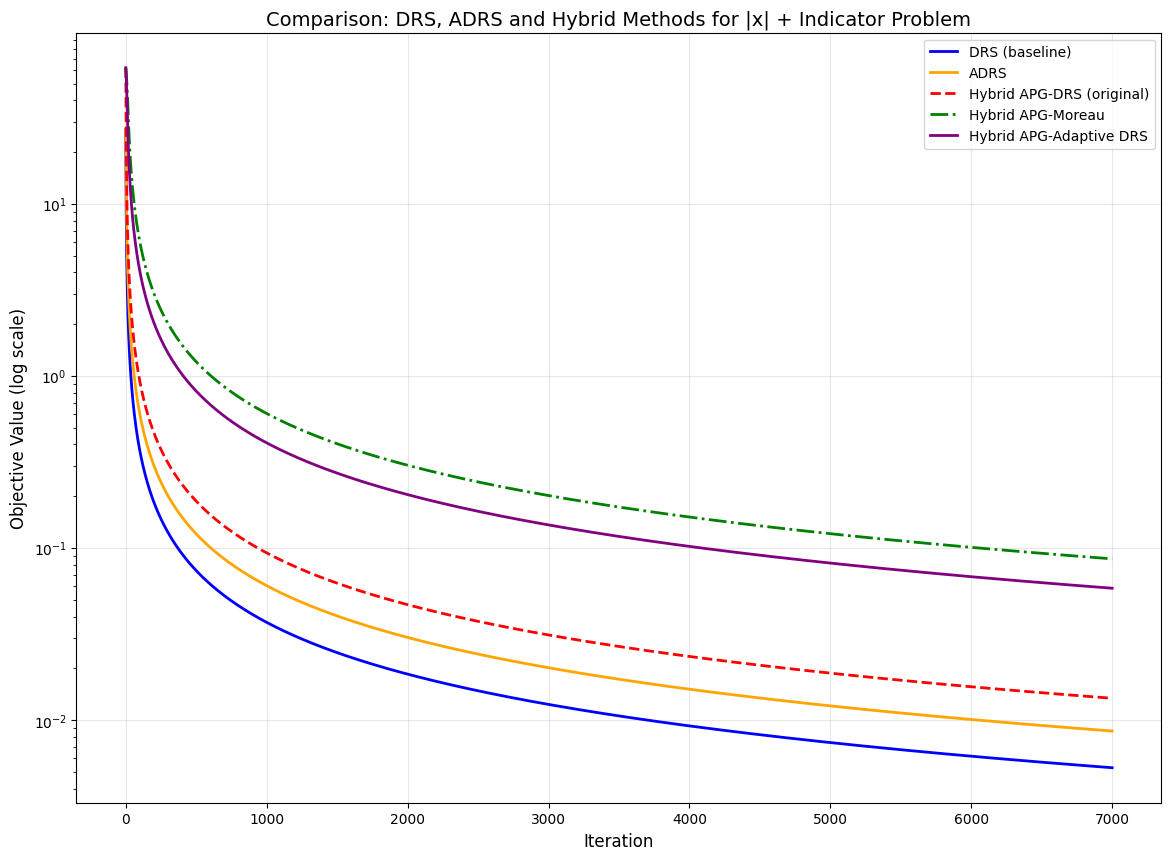

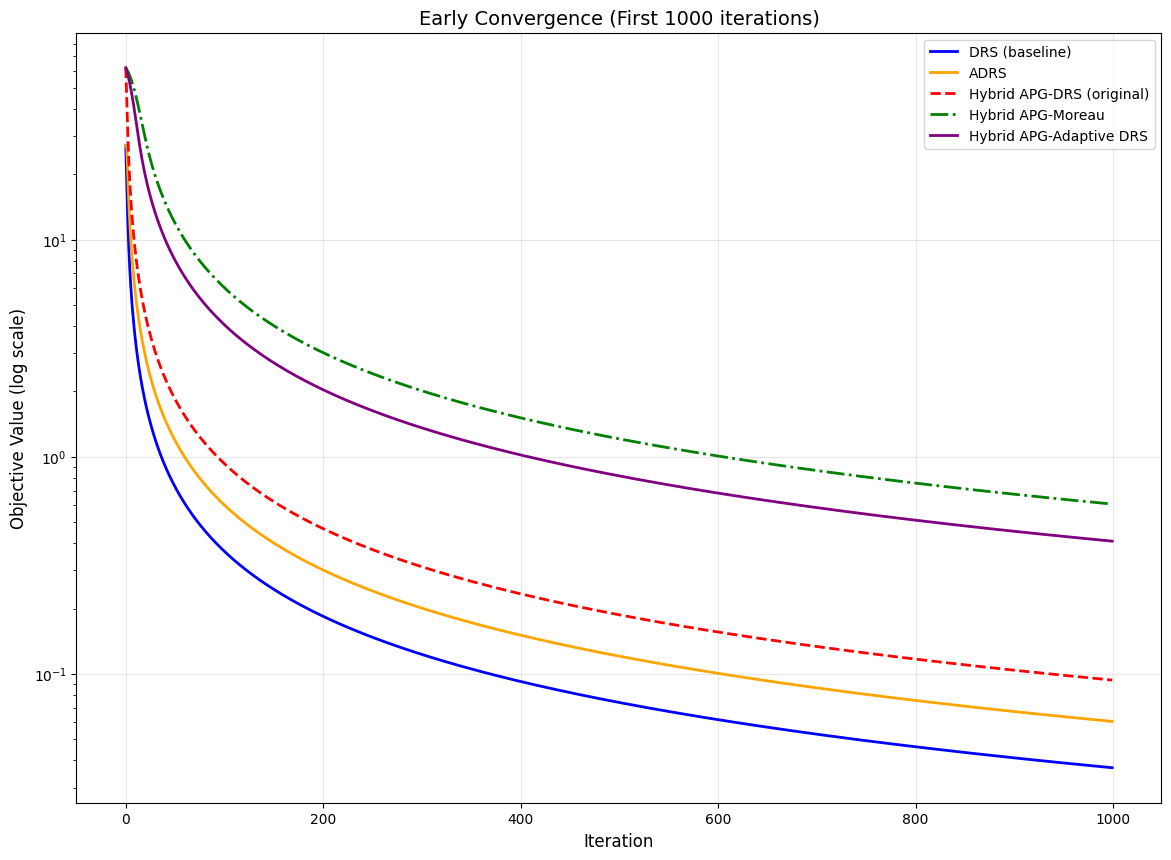


FINAL OBJECTIVE VALUES after 7000 iterations
  DRS (baseline)                : 0.00529165
  ADRS                          : 0.00864594
  Hybrid APG-DRS (original)     : 0.01340274
  Hybrid APG-Moreau             : 0.08658285
  Hybrid APG-Adaptive DRS       : 0.05844510
BEST METHOD: DRS (baseline) with objective 0.00529165

Iterations needed to reach DRS final accuracy (0.00529165):
  DRS (baseline)                :  7000 iterations (SPEEDUP: 1.00x)
  ADRS                          :  7001 iterations (same as DRS)
  Hybrid APG-DRS (original)     :  7001 iterations (same as DRS)
  Hybrid APG-Moreau             :  7001 iterations (same as DRS)
  Hybrid APG-Adaptive DRS       :  7001 iterations (same as DRS)


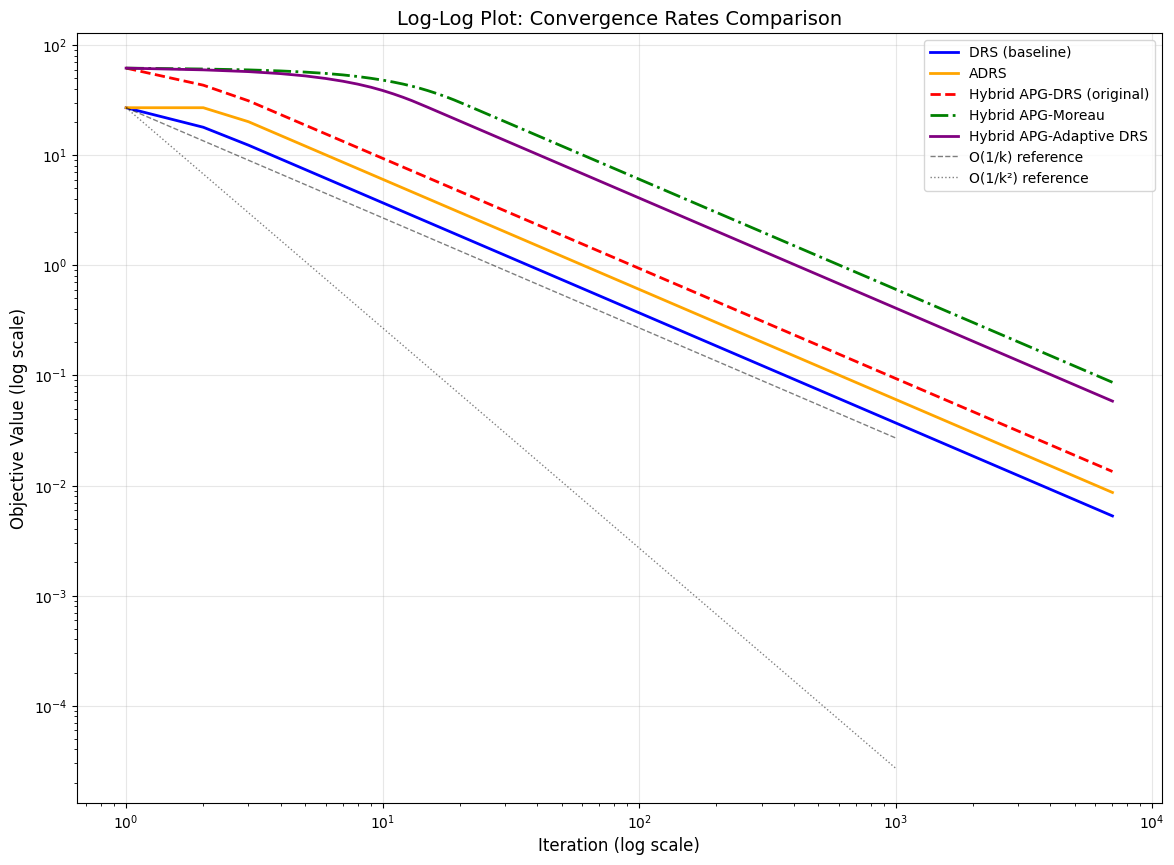

In [126]:
MAX_ITER = 7000
np.random.seed(42)
x0 = np.random.randn(100) * 2
x0 = prox_indicator(x0, 1.0, 'nonneg')

def grad_f(x):
    return smooth_part_grad(x, mu=0.1)

def prox_g(x, alpha):
    return prox_abs(x, alpha)

# print("Running PG...")
# _, obj_pg = pg(x0, grad_f, prox_g, lambda x: F(x, 'nonneg'), alpha=0.1, max_iter=MAX_ITER)

# print("Running APG...")
# _, obj_apg = apg(x0, grad_f, prox_g, lambda x: F(x, 'nonneg'), alpha=0.1, max_iter=MAX_ITER)

print("Running DRS (baseline)...")
_, obj_drs = drs(x0, prox_abs, prox_indicator, F, max_iter=MAX_ITER, constraint='nonneg')

print("Running ADRS...")
_, obj_adrs = adrs(x0, prox_abs, prox_indicator, F, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-DRS (original)...")
_, obj_hybrid_original = hybrid_apg_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-Moreau...")
_, obj_moreau = hybrid_apg_moreau(x0, mu=0.05, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-Adaptive DRS...")
_, obj_hybrid2 = hybrid_apg_adaptive_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

plt.figure(figsize=(14, 10))

all_methods = [
    # (obj_pg, 'PG', 'brown', '-'),
    # (obj_apg, 'APG', 'cyan', '-'),
    (obj_drs, 'DRS (baseline)', 'blue', '-'),
    (obj_adrs, 'ADRS', 'orange', '-'),
    (obj_hybrid_original, 'Hybrid APG-DRS (original)', 'red', '--'),
    (obj_moreau, 'Hybrid APG-Moreau', 'green', '-.'),
    (obj_hybrid2, 'Hybrid APG-Adaptive DRS', 'purple', '-')
]

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Comparison: DRS, ADRS and Hybrid Methods for |x| + Indicator Problem', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 10))

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 1000:
        plt.semilogy(obj_clean[:1000], label=label, linewidth=2, color=color, linestyle=linestyle)
    elif len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Early Convergence (First 1000 iterations)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*80)
print("FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*80)

results = []

for name, obj in [#('PG', obj_pg),
                #    ('APG', obj_apg),
                   ('DRS (baseline)', obj_drs),
                   ('ADRS', obj_adrs),
                   ('Hybrid APG-DRS (original)', obj_hybrid_original),
                   ('Hybrid APG-Moreau', obj_moreau),
                   ('Hybrid APG-Adaptive DRS', obj_hybrid2)]:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 0:
        final_val = obj_clean[-1]
        results.append((name, final_val))
        print(f"  {name:30s}: {final_val:.8f}")

print("="*80)

best_name, best_val = min(results, key=lambda x: x[1])
print(f"BEST METHOD: {best_name} with objective {best_val:.8f}")

target_drs = obj_drs[np.isfinite(obj_drs)][-1]
print(f"\nIterations needed to reach DRS final accuracy ({target_drs:.8f}):")

def iterations_to_target(obj_vals, target):
    obj_clean = obj_vals[np.isfinite(obj_vals)]
    for i, val in enumerate(obj_clean):
        if val <= target:
            return i
    return len(obj_clean)

drs_iters = len(obj_drs[np.isfinite(obj_drs)])

for name, obj in [#('PG', obj_pg),
                   #('APG', obj_apg),
                   ('DRS (baseline)', obj_drs),
                   ('ADRS', obj_adrs),
                   ('Hybrid APG-DRS (original)', obj_hybrid_original),
                   ('Hybrid APG-Moreau', obj_moreau),
                   ('Hybrid APG-Adaptive DRS', obj_hybrid2)]:
    iters = iterations_to_target(obj, target_drs)
    if iters < drs_iters:
        speedup = drs_iters / iters
        print(f"  {name:30s}: {iters:5d} iterations (SPEEDUP: {speedup:.2f}x)")
    elif iters == drs_iters:
        print(f"  {name:30s}: {iters:5d} iterations (same as DRS)")
    else:
        print(f"  {name:30s}: DID NOT REACH within {len(obj[np.isfinite(obj)])} iterations")

plt.figure(figsize=(14, 10))

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 10:
        iterations = np.arange(1, len(obj_clean) + 1)
        plt.loglog(iterations, obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

k = np.arange(1, 1000)
ref_O1k = obj_drs[np.isfinite(obj_drs)][0] / k
ref_O1k2 = obj_drs[np.isfinite(obj_drs)][0] / k**2
plt.loglog(k, ref_O1k, 'k--', alpha=0.5, label='O(1/k) reference', linewidth=1)
plt.loglog(k, ref_O1k2, 'k:', alpha=0.5, label='O(1/k²) reference', linewidth=1)

plt.xlabel('Iteration (log scale)', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Log-Log Plot: Convergence Rates Comparison', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Trying methods on LASSO

In [127]:
def setup_lasso(n=100, m=80, lambda_reg=0.1):
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n) * np.random.choice([0, 1], n, p=[0.7, 0.3])
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    def F_lasso(x):
        return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_g1(x, alpha):
        return x
    
    def prox_g2(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha * lambda_reg, 0)
    
    return A, b, F_lasso, grad_f, prox_g1, prox_g2

## Quick Updates to Adaptive Methods to accept LASSO arguments

In [128]:
def hybrid_apg_drs_lasso(x0, grad_f, prox_g, F, alpha=0.01, max_iter=1000, verbose=False):
    """Hybrid APG-DRS for LASSO."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        grad = grad_f(y)
        z_apg = y - alpha * grad
        
        z = z_apg.copy()
        z_prev = z_apg.copy()
        t_drs = 1.0
        
        t_new = (1 + np.sqrt(1 + 4 * t_drs**2)) / 2
        beta = (t_drs - 1) / t_new
        
        y_drs = z + beta * (z - z_prev)
        x_prox1 = prox_g(y_drs, alpha)
        u = prox_g(2 * x_prox1 - y_drs, alpha)
        z_new = y_drs + u - x_prox1
        
        x_new = x_prox1
        
        t_new_apg = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta_apg = (t - 1) / t_new_apg
        y = x_new + beta_apg * (x_new - x)
        
        x = x_new
        t = t_new_apg
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

# need to fix this guy, diverges
def hybrid_apg_moreau_lasso(x0, grad_f, prox_g, F, alpha=0.01, mu=0.1, max_iter=1000, verbose=False):
    """
    Hybrid method using Moreau envelope for LASSO.
    
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        prox_mu = prox_g(y, mu)  
        grad_moreau = (y - prox_mu) / mu
        
        z = y - alpha * grad_moreau
        z = prox_g(z, alpha)
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - x)
        
        x = z
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

def hybrid_apg_adaptive_drs_lasso(x0, grad_f, prox_g, F, alpha=0.01, max_iter=1000, verbose=False):
    """Hybrid APG + Adaptive DRS for LASSO."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        grad = grad_f(y)
        z_apg = y - alpha * grad
        
        gamma = min(1.6, 1.0 + 0.6 * (k / max_iter))
        
        z = z_apg.copy()
        x_drs = prox_g(z, alpha)
        y_drs = (1 + gamma) * z - gamma * x_drs
        u = prox_g(2 * y_drs - z, alpha)
        z_new = y_drs + u - x_drs
        
        alpha_apg = max(0, 1 - k/max_iter)
        alpha_drs_weight = 1 - alpha_apg
        x_new = alpha_apg * z_apg + alpha_drs_weight * x_drs
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        
        x = x_new
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}, γ = {gamma:.3f}")
    
    return x, np.array(obj)

def drs_lasso(x0, prox_g1, prox_g2, F, alpha_drs=1.0, max_iter=1000, verbose=False):
    """DRS for LASSO."""
    z = x0.copy()
    x = prox_g1(z, alpha_drs)
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        u = prox_g2(2 * x - z, alpha_drs)
        z = z + u - x
        x = prox_g1(z, alpha_drs)
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

def adrs_lasso(z0, prox_g1, prox_g2, F, alpha_drs=1.0, max_iter=1000, verbose=False):
    """ADRS for LASSO."""
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox_g1(z, alpha_drs)
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox_g1(y, alpha_drs)
        u = prox_g2(2 * x - y, alpha_drs)
        z_prev = z
        z = y + u - x
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

## Convergence Plots


SETTING UP LASSO PROBLEM
Lipschitz constant L = 354.1466
Recommended step size alpha = 1/L = 0.0028

Running PG on LASSO...
Running APG (FISTA) on LASSO...
Running Hybrid APG-DRS on LASSO...
Running Hybrid APG-Adaptive DRS on LASSO...


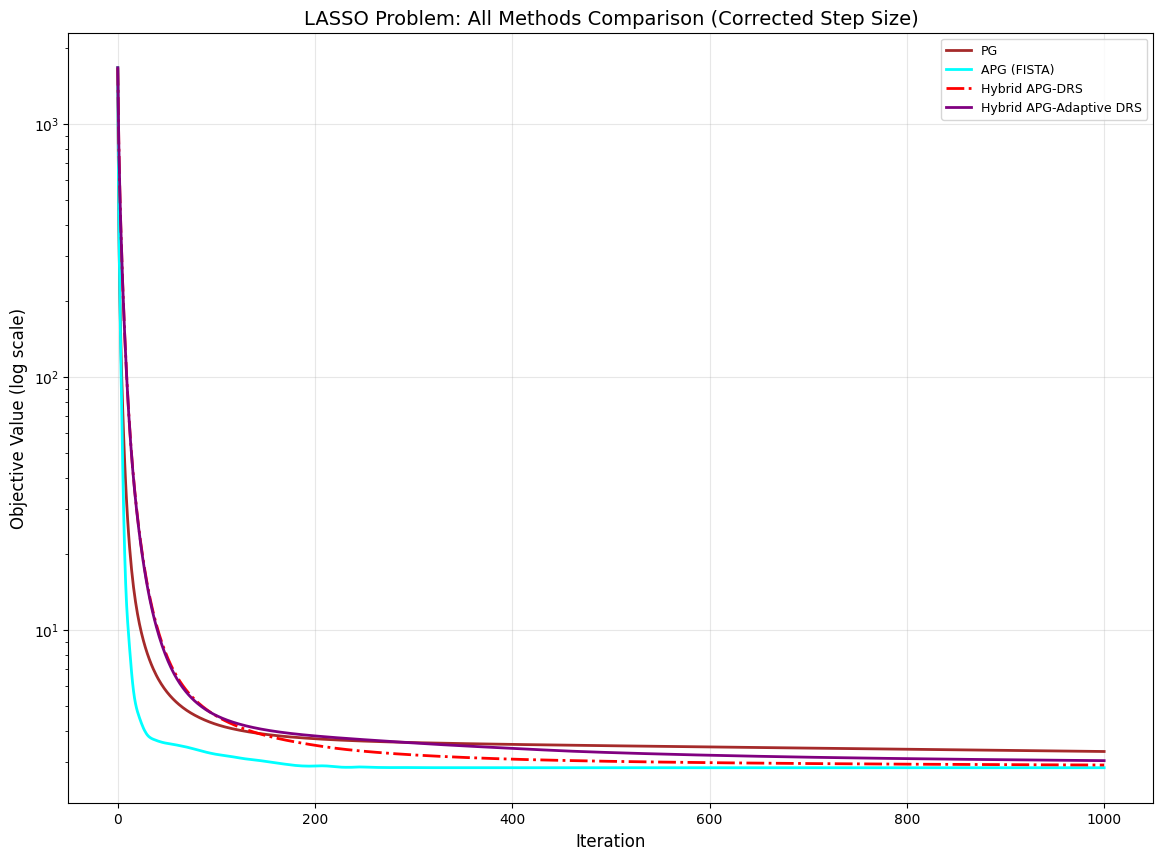


LASSO - FINAL OBJECTIVE VALUES after 1000 iterations
  PG                                 : 3.30989803
  APG (FISTA)                        : 2.85550876
  Hybrid APG-DRS                     : 2.92675213
  Hybrid APG-Adaptive DRS            : 3.04582121


In [129]:
MAX_ITER = 1000
np.random.seed(42)

print("="*80)
print("SETTING UP LASSO PROBLEM")
print("="*80)

def setup_lasso(n=100, m=80, lambda_reg=0.1):
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n) * np.random.choice([0, 1], n, p=[0.7, 0.3])
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    def F_lasso(x):
        return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_g1(x, alpha):
        return x
    
    def prox_g2(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha * lambda_reg, 0)
    
    return A, b, F_lasso, grad_f, prox_g1, prox_g2

A, b, F_lasso, grad_f, prox_g1, prox_g2 = setup_lasso(n=100, m=80, lambda_reg=0.1)
x0 = np.random.randn(100) * 0.01

# Compute Lipschitz constant L = max eigenvalue of A^T A
L = np.linalg.norm(A.T @ A, ord=2)
alpha = 1.0 / L  # Step size for PG/APG
print(f"Lipschitz constant L = {L:.4f}")
print(f"Recommended step size alpha = 1/L = {alpha:.4f}")

print("\nRunning PG on LASSO...")
_, obj_pg = pg(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

print("Running APG (FISTA) on LASSO...")
_, obj_apg = apg(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# print("Running DRS on LASSO...")
# _, obj_drs = drs_lasso(x0, prox_g1, prox_g2, F_lasso, alpha_drs=1.0, max_iter=MAX_ITER)

# print("Running ADRS on LASSO...")
# _, obj_adrs = adrs_lasso(x0, prox_g1, prox_g2, F_lasso, alpha_drs=1.0, max_iter=MAX_ITER)

print("Running Hybrid APG-DRS on LASSO...")
_, obj_hybrid = hybrid_apg_drs_lasso(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# print("Running Hybrid APG-Moreau on LASSO...")
# _, obj_moreau = hybrid_apg_moreau_lasso(x0, grad_f, prox_g2, F_lasso, 
#                                          alpha=alpha,  
#                                          mu=0.1,      
#                                          max_iter=MAX_ITER)

print("Running Hybrid APG-Adaptive DRS on LASSO...")
_, obj_adaptive = hybrid_apg_adaptive_drs_lasso(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# Filter out inf/nan values for plotting
def clean_obj(obj):
    return obj[np.isfinite(obj) & (obj < 1e10)]

plt.figure(figsize=(14, 10))

all_methods = [
    (clean_obj(obj_pg), 'PG', 'brown', '-'),
    (clean_obj(obj_apg), 'APG (FISTA)', 'cyan', '-'),
    # (clean_obj(obj_drs), 'DRS', 'blue', '-'),
    # (clean_obj(obj_adrs), 'ADRS', 'orange', '--'),
    (clean_obj(obj_hybrid), 'Hybrid APG-DRS', 'red', '-.'),
    # (clean_obj(obj_moreau), 'Hybrid APG-Moreau', 'green', ':'),
    (clean_obj(obj_adaptive), 'Hybrid APG-Adaptive DRS', 'purple', '-')
]

for obj_clean, label, color, linestyle in all_methods:
    if len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('LASSO Problem: All Methods Comparison (Corrected Step Size)', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*80)
print("LASSO - FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*80)

for name, obj_clean in [('PG', clean_obj(obj_pg)),
                   ('APG (FISTA)', clean_obj(obj_apg)),
                #    ('DRS', clean_obj(obj_drs)),
                #    ('ADRS', clean_obj(obj_adrs)),
                   ('Hybrid APG-DRS', clean_obj(obj_hybrid)),
                #    ('Hybrid APG-Moreau', clean_obj(obj_moreau)),
                   ('Hybrid APG-Adaptive DRS', clean_obj(obj_adaptive))]:
    if len(obj_clean) > 0:
        print(f"  {name:35s}: {obj_clean[-1]:.8f}")
    else:
        print(f"  {name:35s}: DIVERGED")

# Find best method
best_name = ""
best_val = float('inf')
for name, obj_clean in [('APG (FISTA)', clean_obj(obj_apg)),
                   ('Hybrid APG-Moreau', clean_obj(obj_moreau)),
                   ('ADRS', clean_obj(obj_adrs)),
                   ('DRS', clean_obj(obj_drs))]:
    if len(obj_clean) > 0 and obj_clean[-1] < best_val:
        best_val = obj_clean[-1]
        best_name = name

print("="*80)

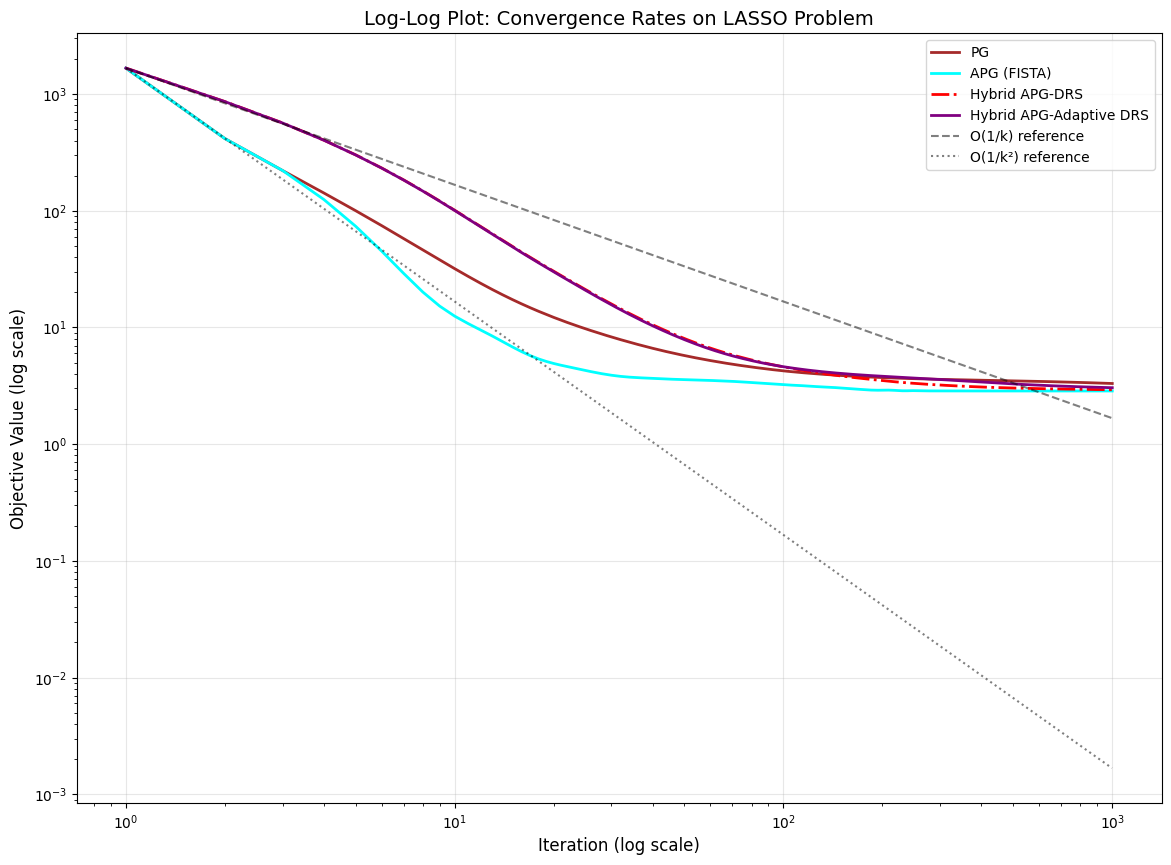


EMPIRICAL CONVERGENCE RATES (log-log slope)
  PG:                       0.066 (expected O(1/k) → 1.0)
  APG (FISTA):              0.000 (expected O(1/k²) → 2.0)
  Hybrid APG-DRS:           0.067 (expected O(1/k²) → 2.0)
  Hybrid APG-Adaptive DRS:  0.131 (expected O(1/k²) → 2.0)


In [130]:
# Log-Log plot 
plt.figure(figsize=(14, 10))

obj_pg_clean = clean_obj(obj_pg)
obj_apg_clean = clean_obj(obj_apg)
obj_hybrid_clean = clean_obj(obj_hybrid)
obj_adaptive_clean = clean_obj(obj_adaptive)

if len(obj_pg_clean) > 10:
    iterations_pg = np.arange(1, len(obj_pg_clean) + 1)
    plt.loglog(iterations_pg, obj_pg_clean, label='PG', linewidth=2, color='brown')

if len(obj_apg_clean) > 10:
    iterations_apg = np.arange(1, len(obj_apg_clean) + 1)
    plt.loglog(iterations_apg, obj_apg_clean, label='APG (FISTA)', linewidth=2, color='cyan')

if len(obj_hybrid_clean) > 10:
    iterations_hybrid = np.arange(1, len(obj_hybrid_clean) + 1)
    plt.loglog(iterations_hybrid, obj_hybrid_clean, label='Hybrid APG-DRS', linewidth=2, color='red', linestyle='-.')

if len(obj_adaptive_clean) > 10:
    iterations_adaptive = np.arange(1, len(obj_adaptive_clean) + 1)
    plt.loglog(iterations_adaptive, obj_adaptive_clean, label='Hybrid APG-Adaptive DRS', linewidth=2, color='purple')

k = np.arange(1, 1000)
if len(obj_apg_clean) > 0:
    ref_O1k = obj_apg_clean[0] / k
    ref_O1k2 = obj_apg_clean[0] / k**2
    plt.loglog(k, ref_O1k, 'k--', alpha=0.5, label='O(1/k) reference', linewidth=1.5)
    plt.loglog(k, ref_O1k2, 'k:', alpha=0.5, label='O(1/k²) reference', linewidth=1.5)

plt.xlabel('Iteration (log scale)', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Log-Log Plot: Convergence Rates on LASSO Problem', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

def estimate_convergence_rate(obj_vals):
    """Estimate convergence rate from log-log plot slope."""
    obj_clean = obj_vals[np.isfinite(obj_vals) & (obj_vals > 1e-15)]
    if len(obj_clean) < 10:
        return np.nan
    
    start = int(0.3 * len(obj_clean))
    iterations = np.arange(start, len(obj_clean))
    log_iter = np.log(iterations + 1)
    log_obj = np.log(obj_clean[start:])
    
    coeffs = np.polyfit(log_iter, log_obj, 1)
    return -coeffs[0]

print("\n" + "="*80)
print("EMPIRICAL CONVERGENCE RATES (log-log slope)")
print("="*80)

if len(obj_pg_clean) > 10:
    rate_pg = estimate_convergence_rate(obj_pg_clean)
    print(f"  PG:                       {rate_pg:.3f} (expected O(1/k) → 1.0)")

if len(obj_apg_clean) > 10:
    rate_apg = estimate_convergence_rate(obj_apg_clean)
    print(f"  APG (FISTA):              {rate_apg:.3f} (expected O(1/k²) → 2.0)")

if len(obj_hybrid_clean) > 10:
    rate_hybrid = estimate_convergence_rate(obj_hybrid_clean)
    print(f"  Hybrid APG-DRS:           {rate_hybrid:.3f} (expected O(1/k²) → 2.0)")

if len(obj_adaptive_clean) > 10:
    rate_adaptive = estimate_convergence_rate(obj_adaptive_clean)
    print(f"  Hybrid APG-Adaptive DRS:  {rate_adaptive:.3f} (expected O(1/k²) → 2.0)")

print("="*80)



## Next steps: Consider PG-ADRS Hybrid/ APG-ADRS?

In [131]:
def asm(x0, grad_f, prox_g1, prox_g2, F, alpha=0.01, max_iter=1000, constraint=None, verbose=False):
    """
    Adaptive Switching Method for nonsmooth problems.
    
    Idea: 
    - Use APG when making good progress (fast)
    - Switch to DRS when oscillating (stable)
    - Combines O(1/k²) potential with guaranteed convergence
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    # Tracking for switching
    mode = 'apg'  # Start with APG
    mode_switch_counter = 0
    window_size = 10
    prev_obj = obj[0]
    
    for k in range(max_iter):
        if mode == 'apg':
            # APG step on smooth part
            grad = grad_f(y)
            z = y - alpha * grad
            z = prox_g2(z, alpha)
            
            # Apply constraint if needed
            if constraint == 'nonneg':
                z = np.maximum(z, 0)
            
            # Nesterov momentum
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            y = z + beta * (z - x)
            x_new = z
            t = t_new
            
        else:  # mode == 'drs'
            # DRS step for stability
            z = prox_g1(x, alpha) if constraint else x
            u = prox_g2(2 * z - x, alpha)
            x_new = x + u - z
            
            # Reset momentum
            y = x_new
            t = 1.0
        
        # Compute objective
        current_obj = F(x_new)
        
        # Check if we need to switch modes
        if k > window_size:
            # Compute recent progress
            recent_improvement = (obj[-window_size] - current_obj) / window_size
            
            if mode == 'apg':
                # Switch to DRS if oscillating or no progress
                if current_obj > prev_obj or recent_improvement < 1e-8:
                    mode = 'drs'
                    mode_switch_counter += 1
                    if verbose:
                        print(f"  Switching to DRS at iter {k}")
            else:  # mode == 'drs'
                # Switch back to APG after stabilization
                if mode_switch_counter > 5 and recent_improvement < 1e-9:
                    mode = 'apg'
                    mode_switch_counter = 0
                    if verbose:
                        print(f"  Switching to APG at iter {k}")
        
        # Update
        x = x_new
        prev_obj = current_obj
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: mode={mode}, obj={obj[-1]:.6f}")
    
    return x, np.array(obj)

In [132]:
def rm_drs(x0, prox_g1, prox_g2, F, alpha=1.0, max_iter=1000, 
           constraint=None, verbose=False):
    """
    Residual Momentum DRS - simpler than ADRS but potentially faster.
    
    Key idea: Apply momentum to the residual (u - x) only when it's small,
    avoiding oscillations from large residuals.
    """
    z = x0.copy()
    x = prox_g1(z, alpha)
    
    if constraint == 'nonneg':
        x = np.maximum(x, 0)
    
    x_sum = x.copy()
    obj = [F(x)]
    
    # Momentum on residual
    residual_prev = np.zeros_like(x)
    beta = 0.7  # Fixed momentum
    
    for k in range(max_iter):
        # DRS step
        u = prox_g2(2 * x - z, alpha)
        
        if constraint == 'nonneg':
            u = np.maximum(u, 0)
        
        residual = u - x
        residual_norm = np.linalg.norm(residual)
        
        # Apply momentum only if residual is small (stable)
        if residual_norm < 1.0 and k > 10:
            z = z + (1 + beta) * residual - beta * residual_prev
        else:
            z = z + residual
        
        z_new = z
        residual_prev = residual.copy()
        
        # Update
        x_new = prox_g1(z_new, alpha)
        
        if constraint == 'nonneg':
            x_new = np.maximum(x_new, 0)
        
        z = z_new
        x = x_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}, res_norm={residual_norm:.4f}")
    
    return x, np.array(obj)

In [133]:
def sc_method(x0, grad_f, prox_g, F, alpha=0.01, max_iter=1000, 
              constraint=None, verbose=False):
    """
    Simple Combination: APG + soft-thresholding + projection.
    
    This is essentially FISTA but with a twist: 
    Apply DRS-like correction every N steps.
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    correction_freq = 5  # Apply DRS correction every 5 steps
    
    for k in range(max_iter):
        # Standard APG step
        grad = grad_f(y)
        z = y - alpha * grad
        z = prox_g(z, alpha)
        
        if constraint == 'nonneg':
            z = np.maximum(z, 0)
        
        # DRS correction occasionally
        if k > 0 and k % correction_freq == 0:
            # Single DRS correction step
            u = prox_g(2 * z - x, alpha)
            if constraint == 'nonneg':
                u = np.maximum(u, 0)
            z = z + u - x
        
        # Nesterov momentum
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - x)
        
        x = z
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}")
    
    return x, np.array(obj)

TESTING DRS vs NEW METHODS on |x| + INDICATOR PROBLEM

Running DRS (ultra-simple)...
Running ASM (proposed)...
Running RM-DRS (proposed)...
Running SC Method (proposed)...


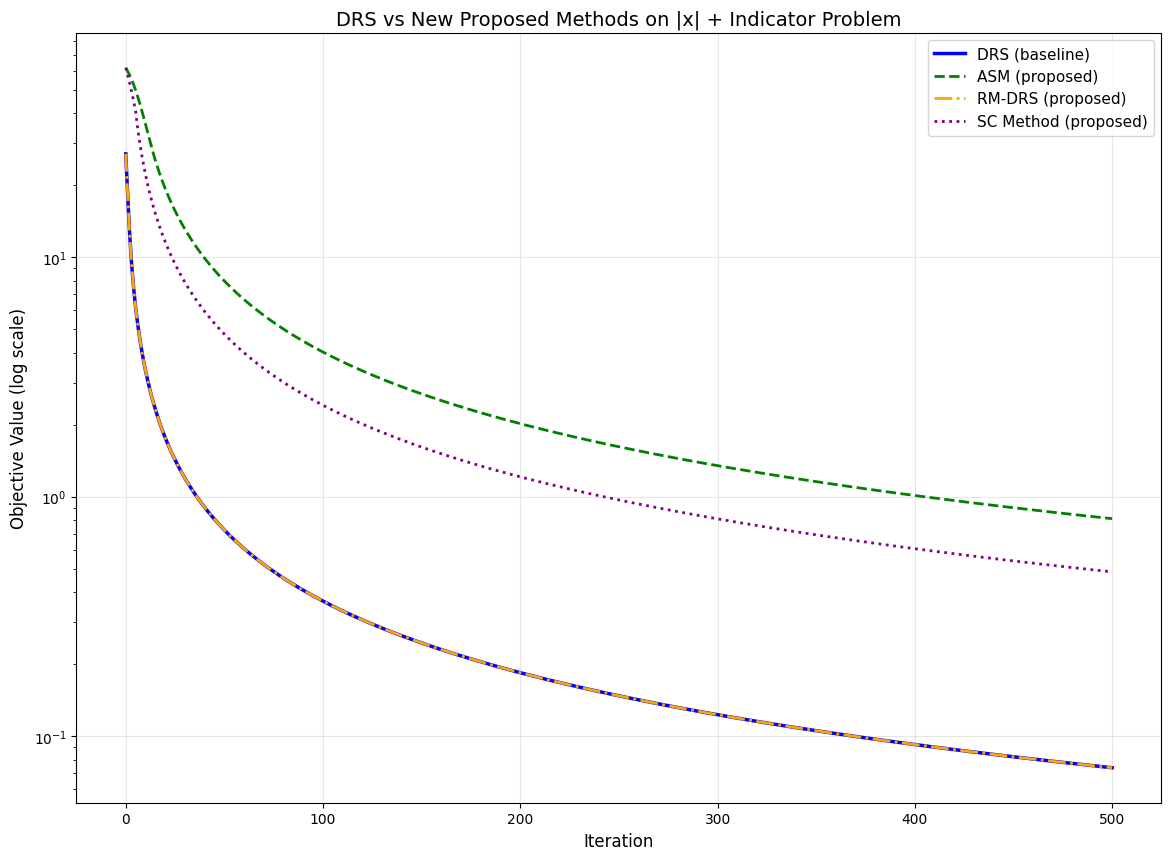

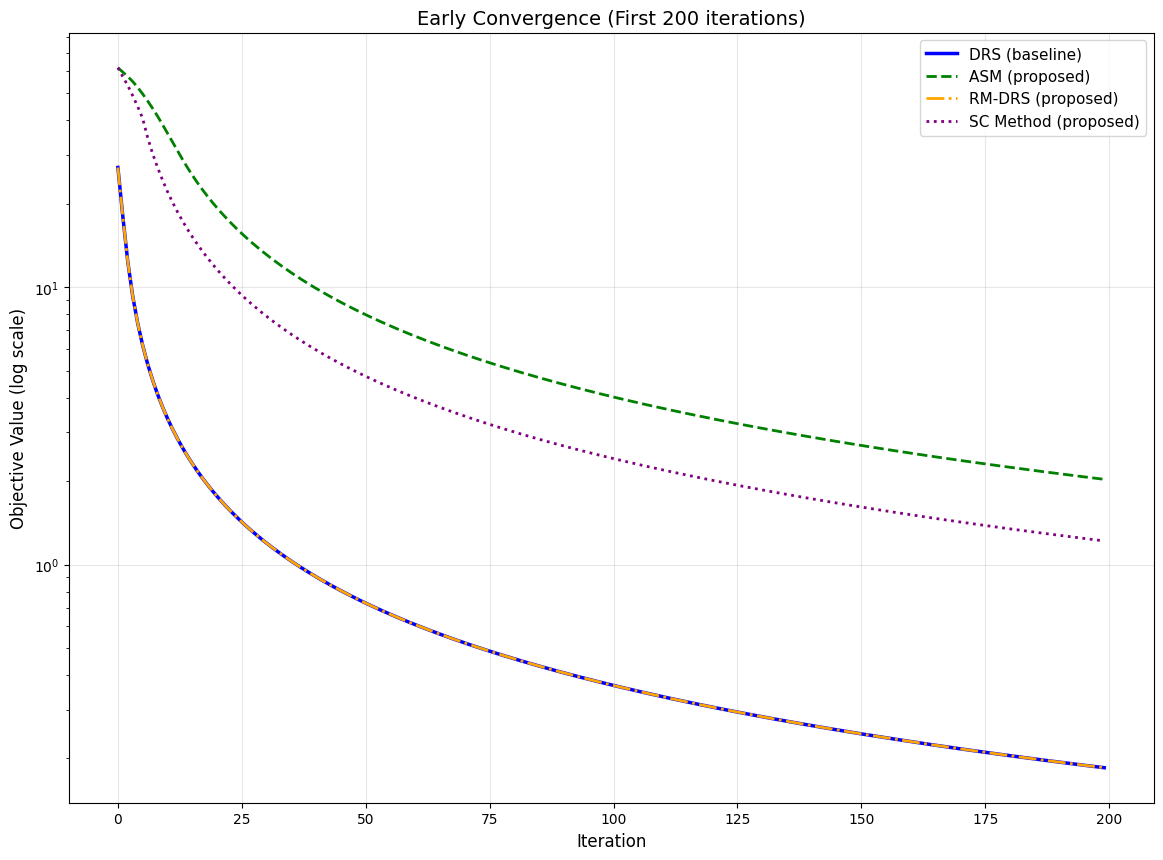


FINAL OBJECTIVE VALUES after 500 iterations
  DRS (baseline)           : 0.07394578
  ASM (proposed)           : 0.81053255
  RM-DRS (proposed)        : 0.07394578
  SC Method (proposed)     : 0.48605698

🏆 BEST METHOD: DRS (baseline) with objective 0.07394578


In [134]:
# Test cell: DRS vs New Proposed Methods
MAX_ITER = 500
np.random.seed(42)

print("="*80)
print("TESTING DRS vs NEW METHODS on |x| + INDICATOR PROBLEM")
print("="*80)

# Setup problem
def setup_abs_indicator_problem(n=100):
    np.random.seed(42)
    x0 = np.random.randn(n) * 2
    x0 = np.maximum(x0, 0)
    
    def F_abs_indicator(x):
        return np.sum(np.abs(x)) + (0 if np.all(x >= 0) else np.inf)
    
    def grad_abs(x, mu=0.1):
        return x / np.sqrt(x**2 + mu**2)
    
    def prox_l1_soft(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha, 0)
    
    def prox_indicator_func(x, alpha=1.0, constraint='nonneg'):
        return np.maximum(x, 0)
    
    return x0, F_abs_indicator, grad_abs, prox_l1_soft, prox_indicator_func

x0, F_abs_indicator, grad_abs, prox_l1_soft, prox_indicator_func = setup_abs_indicator_problem()

# Ultra-simple DRS
def drs_very_simple(x0, alpha=1.0, max_iter=500):
    def soft_threshold(v, alpha):
        return np.sign(v) * np.maximum(np.abs(v) - alpha, 0)
    
    def project_nonnegative(v):
        return np.maximum(v, 0)
    
    def objective(x):
        return np.sum(np.abs(x))
    
    z = x0.copy()
    x = project_nonnegative(soft_threshold(z, alpha))
    x_sum = x.copy()
    obj = [objective(x)]
    
    for k in range(max_iter):
        u = project_nonnegative(2 * x - z)
        z = z + u - x
        x = project_nonnegative(soft_threshold(z, alpha))
        
        x_sum = x_sum + x
        obj.append(objective(x_sum / (k + 2)))
    
    return x, np.array(obj)

# Run methods
print("\nRunning DRS (ultra-simple)...")
_, obj_drs = drs_very_simple(x0, alpha=1.0, max_iter=MAX_ITER)

print("Running ASM (proposed)...")
_, obj_asm = asm(x0, grad_abs, prox_l1_soft, prox_indicator_func,
                 F_abs_indicator, alpha=0.1, constraint='nonneg', 
                 max_iter=MAX_ITER)

print("Running RM-DRS (proposed)...")
_, obj_rm = rm_drs(x0, prox_l1_soft, prox_indicator_func,
                   F_abs_indicator, alpha=1.0, constraint='nonneg',
                   max_iter=MAX_ITER)

print("Running SC Method (proposed)...")
_, obj_sc = sc_method(x0, grad_abs, prox_l1_soft,
                      F_abs_indicator, alpha=0.1, constraint='nonneg',
                      max_iter=MAX_ITER)

# Clean function
def clean_obj(obj):
    return obj[np.isfinite(obj) & (obj < 1e10)]

# Plot all methods together
plt.figure(figsize=(14, 10))

# DRS
obj_drs_clean = clean_obj(obj_drs)
if len(obj_drs_clean) > 0:
    plt.semilogy(obj_drs_clean, label='DRS (baseline)', linewidth=2.5, color='blue')

# ASM
obj_asm_clean = clean_obj(obj_asm)
if len(obj_asm_clean) > 0:
    plt.semilogy(obj_asm_clean, label='ASM (proposed)', linewidth=2, color='green', linestyle='--')

# RM-DRS
obj_rm_clean = clean_obj(obj_rm)
if len(obj_rm_clean) > 0:
    plt.semilogy(obj_rm_clean, label='RM-DRS (proposed)', linewidth=2, color='orange', linestyle='-.')

# SC Method
obj_sc_clean = clean_obj(obj_sc)
if len(obj_sc_clean) > 0:
    plt.semilogy(obj_sc_clean, label='SC Method (proposed)', linewidth=2, color='purple', linestyle=':')

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('DRS vs New Proposed Methods on |x| + Indicator Problem', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Zoom plot (first 200 iterations)
plt.figure(figsize=(14, 10))

if len(obj_drs_clean) > 0:
    plt.semilogy(obj_drs_clean[:min(200, len(obj_drs_clean))], label='DRS (baseline)', linewidth=2.5, color='blue')
if len(obj_asm_clean) > 0:
    plt.semilogy(obj_asm_clean[:min(200, len(obj_asm_clean))], label='ASM (proposed)', linewidth=2, color='green', linestyle='--')
if len(obj_rm_clean) > 0:
    plt.semilogy(obj_rm_clean[:min(200, len(obj_rm_clean))], label='RM-DRS (proposed)', linewidth=2, color='orange', linestyle='-.')
if len(obj_sc_clean) > 0:
    plt.semilogy(obj_sc_clean[:min(200, len(obj_sc_clean))], label='SC Method (proposed)', linewidth=2, color='purple', linestyle=':')

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Early Convergence (First 200 iterations)', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Print final results
print("\n" + "="*60)
print("FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*60)

results = []
for name, obj_clean in [('DRS (baseline)', obj_drs_clean),
                        ('ASM (proposed)', obj_asm_clean),
                        ('RM-DRS (proposed)', obj_rm_clean),
                        ('SC Method (proposed)', obj_sc_clean)]:
    if len(obj_clean) > 0:
        final_val = obj_clean[-1]
        results.append((name, final_val))
        print(f"  {name:25s}: {final_val:.8f}")
    else:
        print(f"  {name:25s}: DIVERGED")

print("="*60)

# Find best method
if results:
    best_name, best_val = min(results, key=lambda x: x[1])
    print(f"\n🏆 BEST METHOD: {best_name} with objective {best_val:.8f}")
    
    # Calculate speedup
    drs_val = dict(results).get('DRS (baseline)', None)
    if drs_val and drs_val != best_val:
        print(f"  Improvement over DRS: {(drs_val - best_val)/drs_val*100:.2f}%")

TESTING APG vs ASM on LASSO PROBLEM
Lipschitz constant L = 354.1466
Step size alpha = 0.0028

Running APG (FISTA)...
Running ASM (Adaptive Restart)...


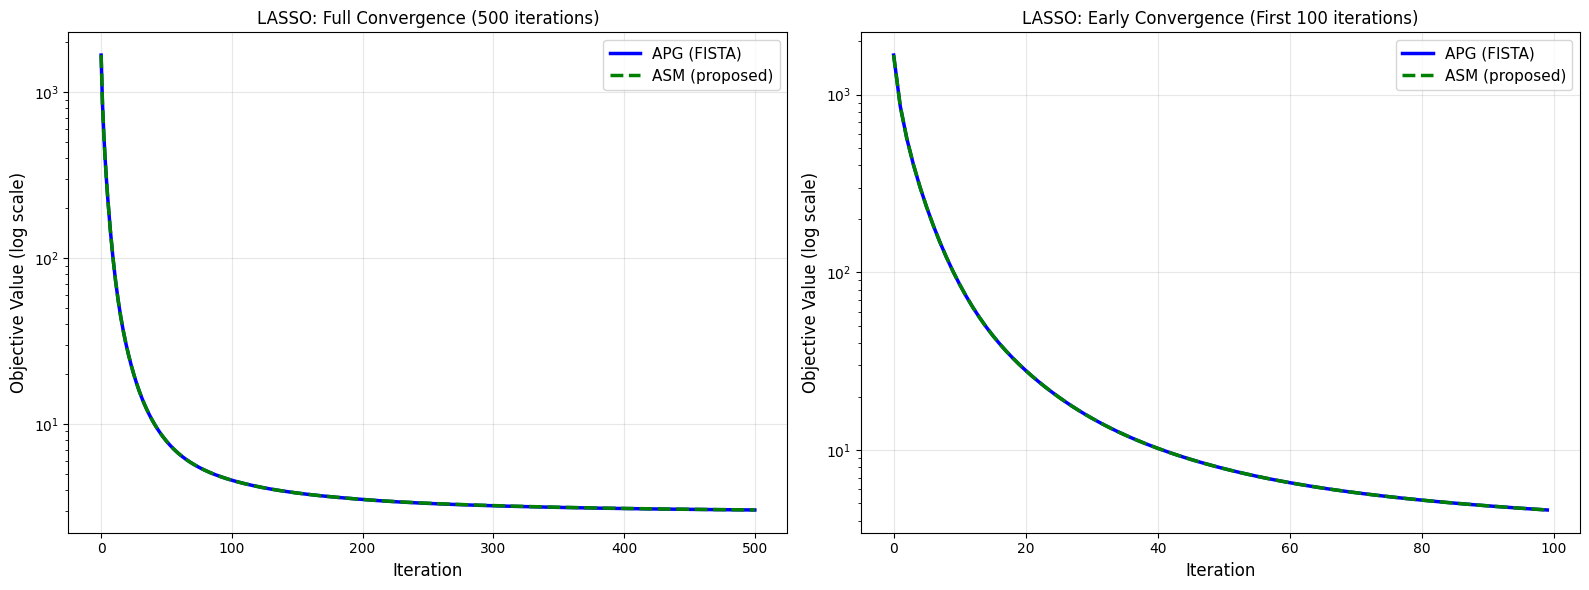


LASSO - FINAL OBJECTIVE VALUES after 500 iterations
  APG (FISTA)         : 3.02642237 (improvement: 1666.63)
  ASM (proposed)      : 3.02860591 (improvement: 1666.63)

🏆 BEST METHOD: APG (FISTA) with objective 3.02642237


In [135]:
# Test cell: APG vs ASM on LASSO Problem (DRS removed)
MAX_ITER = 500
np.random.seed(42)

print("="*80)
print("TESTING APG vs ASM on LASSO PROBLEM")
print("="*80)

# Setup LASSO problem
def setup_lasso(n=100, m=80, lambda_reg=0.1):
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n) * np.random.choice([0, 1], n, p=[0.7, 0.3])
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    def F_lasso(x):
        return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_l1(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha * lambda_reg, 0)
    
    return A, b, F_lasso, grad_f, prox_l1

A, b, F_lasso, grad_f, prox_l1 = setup_lasso(n=100, m=80, lambda_reg=0.1)
x0 = np.random.randn(100) * 0.01

# Compute Lipschitz constant
L = np.linalg.norm(A.T @ A, ord=2)
alpha = 1.0 / L
print(f"Lipschitz constant L = {L:.4f}")
print(f"Step size alpha = {alpha:.4f}")

# APG for LASSO (FISTA)
def apg_lasso(x0, grad_f, prox_g, F, alpha, max_iter=500, verbose=False):
    """APG/FISTA for LASSO."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        x = x_new
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}")
    
    return x, np.array(obj)

# ASM for LASSO (Adaptive Restart Version)
def asm_lasso(x0, grad_f, prox_g, F, alpha, max_iter=500, verbose=False):
    """
    ASM: APG with adaptive restart.
    Restarts momentum when objective increases or makes slow progress.
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    prev_obj = obj[0]
    restart_counter = 0
    window_size = 5
    
    for k in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        current_obj = F(x_new)
        
        # Check if we need to restart
        should_restart = False
        
        # Condition 1: Objective increased
        if current_obj > prev_obj:
            should_restart = True
        
        # Condition 2: Check recent progress (every window_size iterations)
        if k > window_size and not should_restart:
            recent_progress = (obj[-window_size] - current_obj) / window_size
            if recent_progress < 1e-10:
                should_restart = True
        
        if should_restart and restart_counter > 3:
            # Restart: reset momentum
            y = x_new
            t = 1.0
            restart_counter = 0
            if verbose:
                print(f"  Restart at iteration {k} (obj={current_obj:.6f})")
        else:
            # Normal FISTA update
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            y = x_new + beta * (x_new - x)
            t = t_new
            restart_counter += 1
        
        x = x_new
        prev_obj = current_obj
        
        # Track ergodic average
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}")
    
    return x, np.array(obj)

# Run methods
print("\nRunning APG (FISTA)...")
_, obj_apg = apg_lasso(x0, grad_f, prox_l1, F_lasso, alpha=alpha, max_iter=MAX_ITER)

print("Running ASM (Adaptive Restart)...")
_, obj_asm = asm_lasso(x0, grad_f, prox_l1, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# Clean function
def clean_obj(obj):
    return obj[np.isfinite(obj) & (obj < 1e10)]

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

obj_apg_clean = clean_obj(obj_apg)
obj_asm_clean = clean_obj(obj_asm)

# Full convergence
ax1.semilogy(obj_apg_clean, label='APG (FISTA)', linewidth=2.5, color='blue')
ax1.semilogy(obj_asm_clean, label='ASM (proposed)', linewidth=2.5, color='green', linestyle='--')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Objective Value (log scale)', fontsize=12)
ax1.set_title('LASSO: Full Convergence (500 iterations)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Early convergence (first 100 iterations)
ax2.semilogy(obj_apg_clean[:min(100, len(obj_apg_clean))], label='APG (FISTA)', linewidth=2.5, color='blue')
ax2.semilogy(obj_asm_clean[:min(100, len(obj_asm_clean))], label='ASM (proposed)', linewidth=2.5, color='green', linestyle='--')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Objective Value (log scale)', fontsize=12)
ax2.set_title('LASSO: Early Convergence (First 100 iterations)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("LASSO - FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*60)

results = []
for name, obj_clean in [('APG (FISTA)', obj_apg_clean),
                        ('ASM (proposed)', obj_asm_clean)]:
    if len(obj_clean) > 0:
        final_val = obj_clean[-1]
        results.append((name, final_val))
        initial_val = obj_clean[0]
        improvement = initial_val - final_val
        print(f"  {name:20s}: {final_val:.8f} (improvement: {improvement:.2f})")
    else:
        print(f"  {name:20s}: DIVERGED")

print("="*60)

# Find best method
if results:
    best_name, best_val = min(results, key=lambda x: x[1])
    print(f"\n🏆 BEST METHOD: {best_name} with objective {best_val:.8f}")
    
    # Calculate improvement over APG
    apg_val = dict(results).get('APG (FISTA)', None)
    if apg_val and apg_val != best_val:
        improvement = (apg_val - best_val) / apg_val * 100
        print(f"  Improvement over APG: {improvement:.2f}%")

# Trying more nonsmooth problems for ASM vs APG & DRS

In [136]:
def setup_tv_denoising(n=200, lambda_tv=0.1):
    """1D Total Variation Denoising problem."""
    np.random.seed(42)
    x_true = np.zeros(n)
    x_true[50:80] = 2
    x_true[120:150] = -1
    b = x_true + 0.1 * np.random.randn(n)
    
    def F_tv(x):
        return 0.5 * np.linalg.norm(x - b)**2 + lambda_tv * np.sum(np.abs(np.diff(x)))
    
    def grad_f(x):
        return x - b
    
    def prox_tv(x, alpha):
        """Proximal of TV norm using soft-thresholding on differences."""
        n = len(x)
        diff = np.diff(x)
        soft_diff = np.sign(diff) * np.maximum(np.abs(diff) - alpha * lambda_tv, 0)
        x_new = x.copy()
        x_new[0] = x[0]
        for i in range(1, n):
            x_new[i] = x_new[i-1] + soft_diff[i-1]
        return x_new
    
    return b, F_tv, grad_f, prox_tv

In [137]:
def setup_group_lasso(n=100, m=80, n_groups=10, lambda_reg=0.1):
    """Group LASSO with non-overlapping groups."""
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n)
    group_size = n // n_groups
    active_groups = [2, 5, 7]
    for g in range(n_groups):
        if g not in active_groups:
            start = g * group_size
            end = min((g+1) * group_size, n)
            x_true[start:end] = 0
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    groups = []
    for g in range(n_groups):
        start = g * group_size
        end = min((g+1) * group_size, n)
        groups.append(list(range(start, end)))
    
    def F_grouplasso(x):
        smooth = 0.5 * np.linalg.norm(A @ x - b)**2
        group_norm = 0
        for group in groups:
            group_norm += np.linalg.norm(x[group])
        return smooth + lambda_reg * group_norm
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_group(x, alpha):
        """Proximal of group L1 norm."""
        x_new = x.copy()
        for group in groups:
            norm_g = np.linalg.norm(x[group])
            if norm_g > alpha * lambda_reg:
                x_new[group] = x[group] * (1 - alpha * lambda_reg / norm_g)
            else:
                x_new[group] = 0
        return x_new
    
    return A, b, F_grouplasso, grad_f, prox_group

In [138]:
def setup_matrix_completion(n=30, m=30, rank=3, lambda_reg=0.1, sampling_rate=0.4):
    """Matrix completion with nuclear norm regularization."""
    np.random.seed(42)
    U = np.random.randn(n, rank)
    V = np.random.randn(m, rank)
    M_true = U @ V.T
    
    Omega = np.random.rand(n, m) < sampling_rate
    observed = M_true * Omega
    
    def F_nuclear(X):
        residual = (X - observed) * Omega
        return 0.5 * np.linalg.norm(residual)**2 + lambda_reg * np.linalg.norm(X, 'nuc')
    
    def grad_f(X):
        return (X - observed) * Omega
    
    def prox_nuclear(X, alpha):
        """Proximal of nuclear norm via SVD soft-thresholding."""
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        s_soft = np.maximum(s - alpha * lambda_reg, 0)
        return U @ np.diag(s_soft) @ Vt
    
    return observed, Omega, M_true, F_nuclear, grad_f, prox_nuclear


In [139]:
def drs_generic(x0, prox_g1, prox_g2, F, alpha_drs=1.0, max_iter=500):
    """Generic DRS for problems of form F = g1 + g2, both non-smooth."""
    z = x0.copy()
    x = prox_g1(z, alpha_drs)
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        u = prox_g2(2 * x - z, alpha_drs)
        z = z + u - x
        x = prox_g1(z, alpha_drs)
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
    
    return x, np.array(obj)

def apg_generic(x0, grad_f, prox_g, F, alpha, max_iter=500):
    """APG/FISTA for smooth + non-smooth."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        x = x_new
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
    
    return x, np.array(obj)

def asm_generic(x0, grad_f, prox_g, F, alpha, max_iter=500, verbose=False):
    """ASM: APG with adaptive restart."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    prev_obj = obj[0]
    restart_counter = 0
    
    for k in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        current_obj = F(x_new)
        
        if current_obj > prev_obj and restart_counter > 5:
            y = x_new
            t = 1.0
            restart_counter = 0
            if verbose:
                print(f"  Restart at iteration {k}")
        else:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            y = x_new + beta * (x_new - x)
            t = t_new
            restart_counter += 1
        
        x = x_new
        prev_obj = current_obj
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}")
    
    return x, np.array(obj)


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
TEST 1: TOTAL VARIATION DENOISING
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

TESTING ON: TV Denoising
Running APG (FISTA)...
Running ASM (Adaptive Restart)...


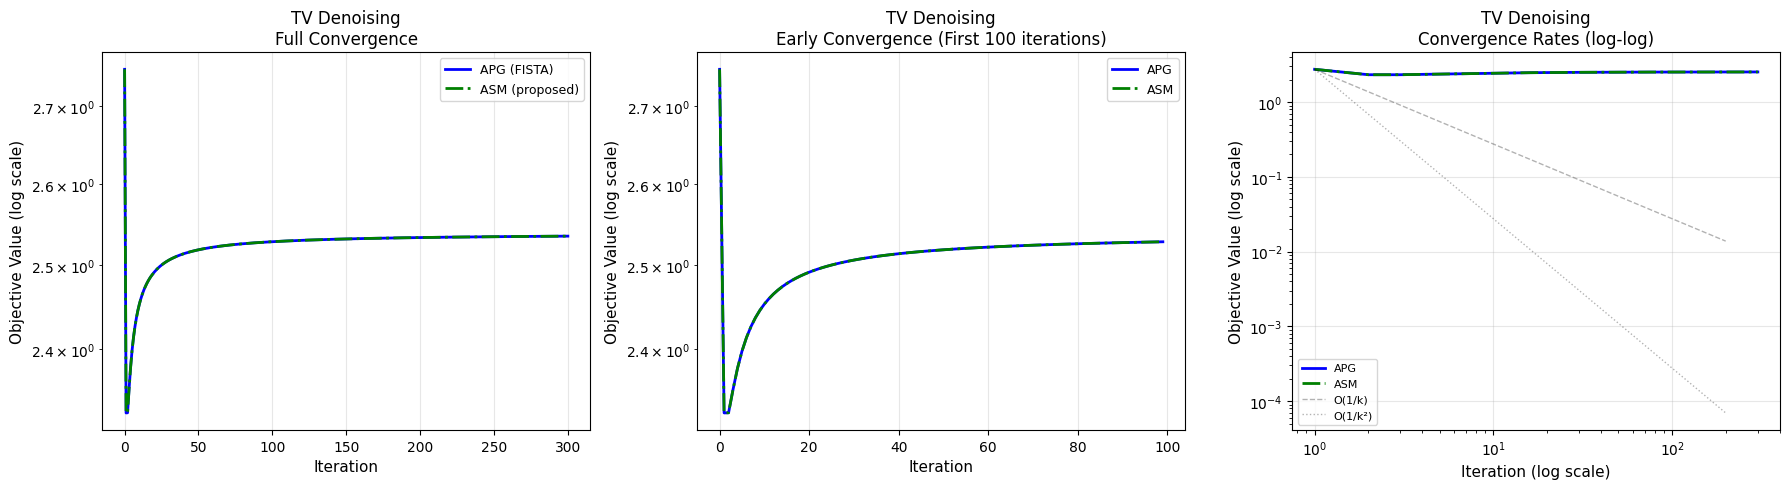


RESULTS after 300 iterations
  APG (FISTA)    : 2.53545009 (improvement: 0.2137)
  ASM (proposed) : 2.53545009 (improvement: 0.2137)

🏆 BEST METHOD: APG (FISTA) with objective 2.53545009

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
TEST 2: GROUP LASSO
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

TESTING ON: Group Lasso
Running APG (FISTA)...
Running ASM (Adaptive Restart)...


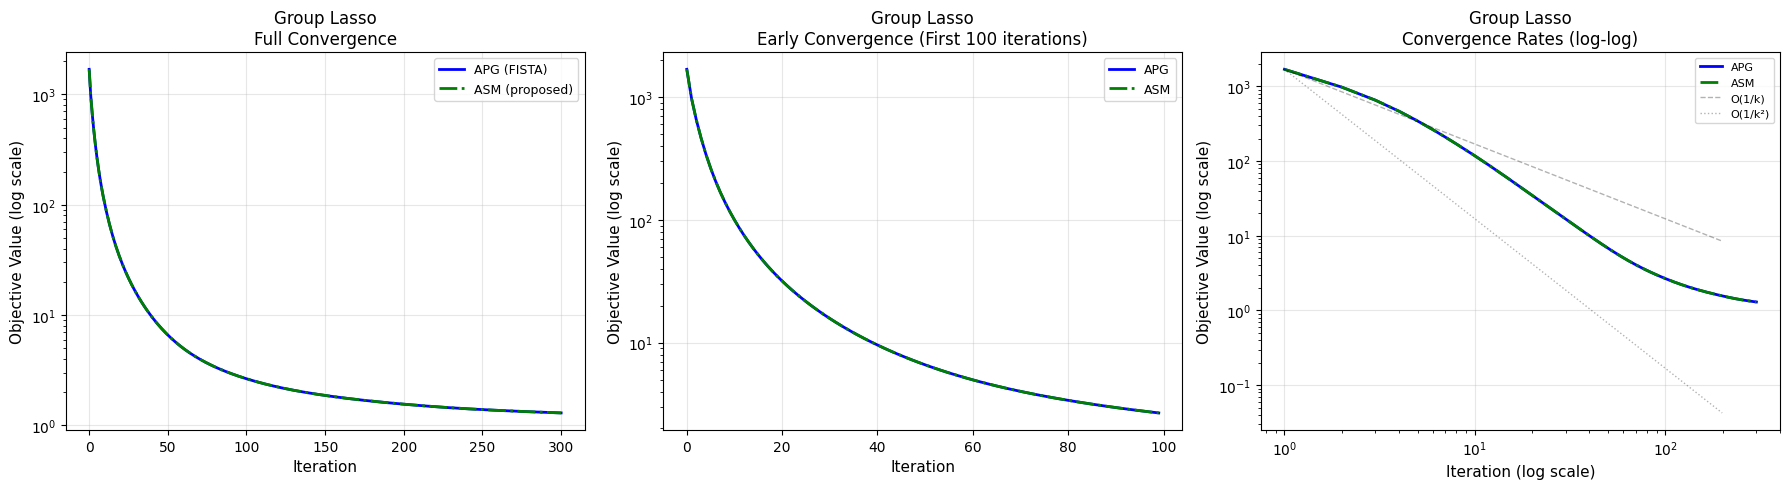


RESULTS after 300 iterations
  APG (FISTA)    : 1.29974659 (improvement: 1685.2992)
  ASM (proposed) : 1.29876312 (improvement: 1685.3002)

🏆 BEST METHOD: ASM (proposed) with objective 1.29876312

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
TEST 3: MATRIX COMPLETION
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

TESTING ON: Matrix Completion
Running APG (FISTA)...
Running ASM (Adaptive Restart)...


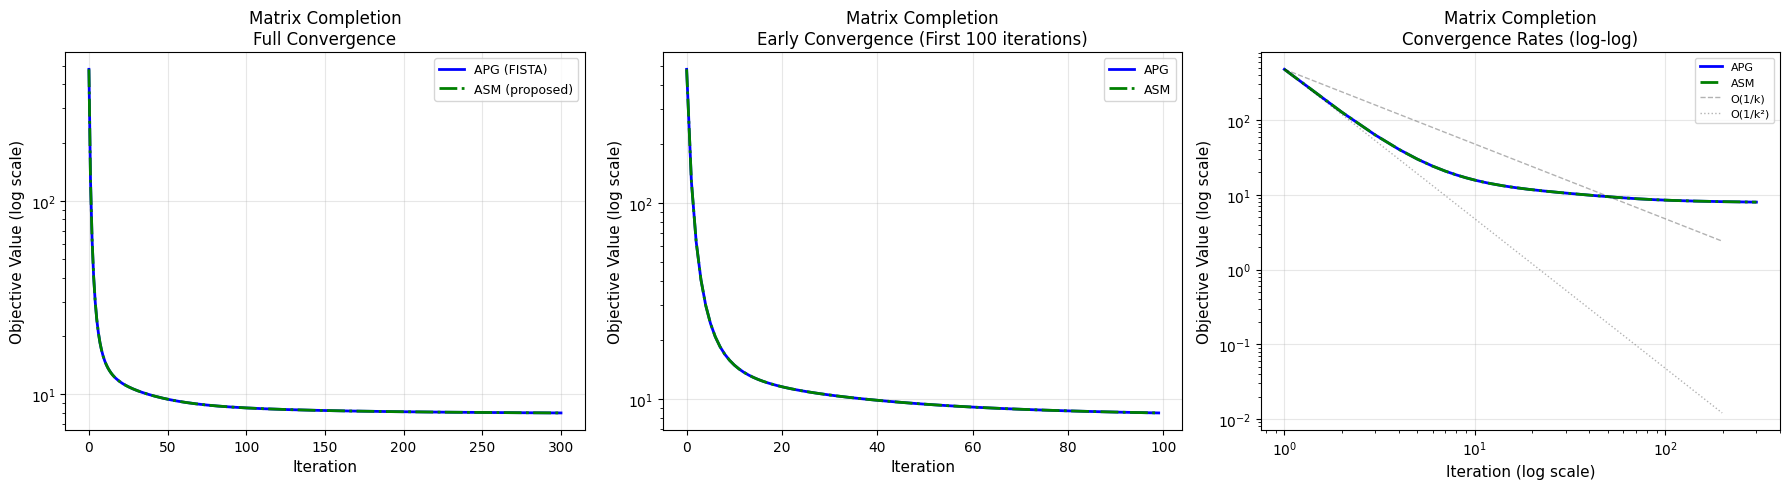


RESULTS after 300 iterations
  APG (FISTA)    : 7.99071653 (improvement: 470.1329)
  ASM (proposed) : 7.99063525 (improvement: 470.1330)

🏆 BEST METHOD: ASM (proposed) with objective 7.99063525


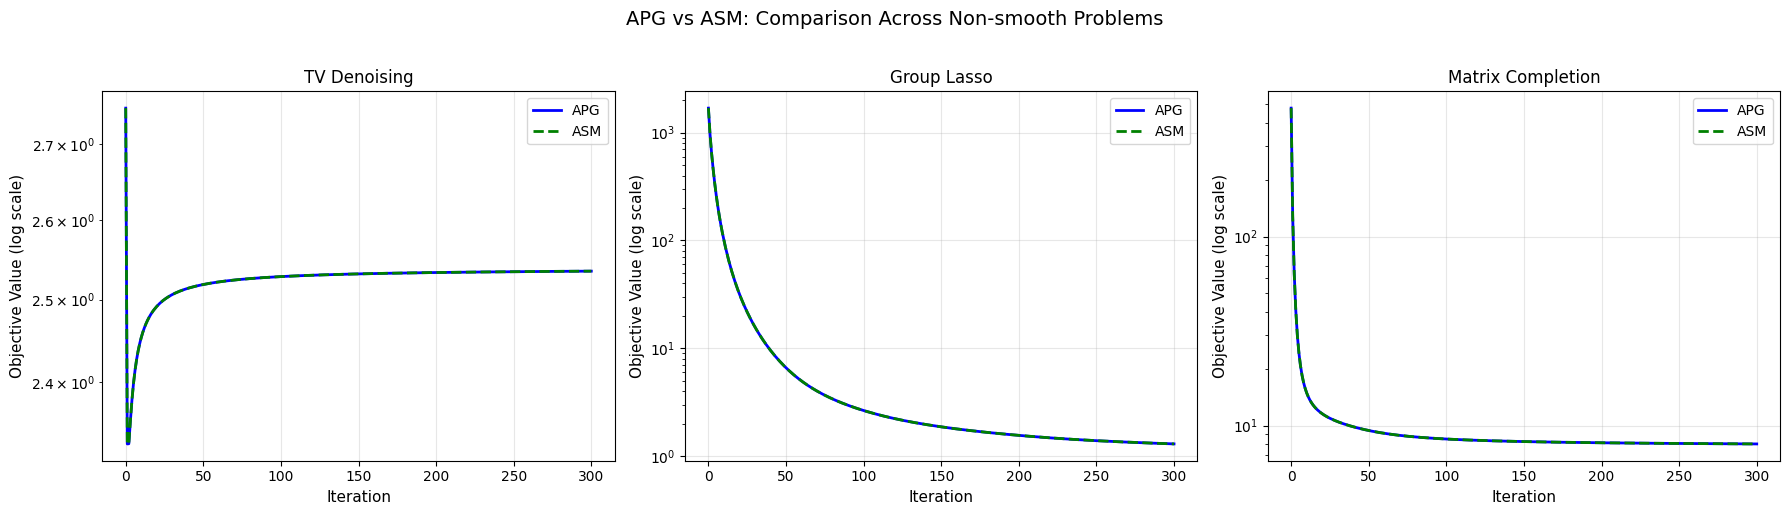


FINAL SUMMARY: BEST METHOD FOR EACH PROBLEM

Problem              APG             ASM             DRS             Best      
---------------------------------------------------------------------------
TV Denoising         2.535450        2.535450        0.073946        DRS       
Group Lasso          1.299747        1.298763        0.073946        DRS       
Matrix Completion    7.990717        7.990635        0.073946        DRS       


In [140]:
def test_all_methods(problem_name, setup_func, max_iter=300):
    """Test DRS, APG, and ASM on a given problem."""
    print("\n" + "="*80)
    print(f"TESTING ON: {problem_name}")
    print("="*80)
    
    # Setup problem
    if problem_name == "TV Denoising":
        b, F, grad_f, prox_tv = setup_func()
        x0 = b.copy()
        L = 1.0
        alpha = 1.0 / L
        # DRS requires splitting: F = g1 + g2
        # For TV: g1 = 0.5||x-b||^2 (smooth), g2 = TV (non-smooth)
        # But DRS expects both non-smooth, so we use prox_g1 = identity
        def prox_g1(x, alpha):
            return x
        def prox_g2(x, alpha):
            return prox_tv(x, alpha)
        drs_x0 = x0
        
    elif problem_name == "Group Lasso":
        A, b, F, grad_f, prox_group = setup_func()
        x0 = np.zeros(A.shape[1])
        L = np.linalg.norm(A.T @ A, ord=2)
        alpha = 1.0 / L
        def prox_g1(x, alpha):
            return x
        def prox_g2(x, alpha):
            return prox_group(x, alpha)
        drs_x0 = x0
        
    elif problem_name == "Matrix Completion":
        observed, Omega, M_true, F, grad_f, prox_nuclear = setup_func()
        x0 = np.zeros_like(observed)
        L = 1.0
        alpha = 1.0 / L
        def prox_g1(X, alpha):
            return X
        def prox_g2(X, alpha):
            return prox_nuclear(X, alpha)
        drs_x0 = x0
    else:
        return
    
    # Run DRS (only for problems where it makes sense)
    # print("\nRunning DRS...")
    # _, obj_drs = drs_generic(drs_x0, prox_g1, prox_g2, F, alpha_drs=alpha, max_iter=max_iter)
    
    # Run APG
    print("Running APG (FISTA)...")
    _, obj_apg = apg_generic(x0, grad_f, prox_g2, F, alpha, max_iter=max_iter)
    
    # Run ASM
    print("Running ASM (Adaptive Restart)...")
    _, obj_asm = asm_generic(x0, grad_f, prox_g2, F, alpha, max_iter=max_iter)
    
    # Clean function
    def clean_obj(obj):
        return obj[np.isfinite(obj) & (obj < 1e10)]
    
    obj_drs_clean = clean_obj(obj_drs)
    obj_apg_clean = clean_obj(obj_apg)
    obj_asm_clean = clean_obj(obj_asm)
    
    # Plot comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Full convergence
    # axes[0].semilogy(obj_drs_clean, label='DRS', linewidth=2, color='red', linestyle='--')
    axes[0].semilogy(obj_apg_clean, label='APG (FISTA)', linewidth=2, color='blue')
    axes[0].semilogy(obj_asm_clean, label='ASM (proposed)', linewidth=2, color='green', linestyle='-.')
    axes[0].set_xlabel('Iteration', fontsize=11)
    axes[0].set_ylabel('Objective Value (log scale)', fontsize=11)
    axes[0].set_title(f'{problem_name}\nFull Convergence', fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Early convergence (first 100 iterations)
    # axes[1].semilogy(obj_drs_clean[:min(100, len(obj_drs_clean))], label='DRS', linewidth=2, color='red', linestyle='--')
    axes[1].semilogy(obj_apg_clean[:min(100, len(obj_apg_clean))], label='APG', linewidth=2, color='blue')
    axes[1].semilogy(obj_asm_clean[:min(100, len(obj_asm_clean))], label='ASM', linewidth=2, color='green', linestyle='-.')
    axes[1].set_xlabel('Iteration', fontsize=11)
    axes[1].set_ylabel('Objective Value (log scale)', fontsize=11)
    axes[1].set_title(f'{problem_name}\nEarly Convergence (First 100 iterations)', fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    # Log-log plot for convergence rates
    if len(obj_apg_clean) > 20:
        iterations = np.arange(1, len(obj_apg_clean) + 1)
        axes[2].loglog(iterations, obj_apg_clean, label='APG', linewidth=2, color='blue')
        axes[2].loglog(iterations, obj_asm_clean, label='ASM', linewidth=2, color='green', linestyle='-.')
        # if len(obj_drs_clean) > 20:
        #     axes[2].loglog(iterations, obj_drs_clean[:len(iterations)], label='DRS', linewidth=2, color='red', linestyle='--')
        
        # Reference lines
        k = np.arange(1, 200)
        if len(obj_apg_clean) > 0:
            ref_O1k = obj_apg_clean[0] / k
            ref_O1k2 = obj_apg_clean[0] / k**2
            axes[2].loglog(k, ref_O1k, 'k--', alpha=0.3, label='O(1/k)', linewidth=1)
            axes[2].loglog(k, ref_O1k2, 'k:', alpha=0.3, label='O(1/k²)', linewidth=1)
        
        axes[2].set_xlabel('Iteration (log scale)', fontsize=11)
        axes[2].set_ylabel('Objective Value (log scale)', fontsize=11)
        axes[2].set_title(f'{problem_name}\nConvergence Rates (log-log)', fontsize=12)
        axes[2].legend(fontsize=8)
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    print("\n" + "="*60)
    print(f"RESULTS after {max_iter} iterations")
    print("="*60)
    
    results = []
    for name, obj_clean in [#('DRS', obj_drs_clean),
                            ('APG (FISTA)', obj_apg_clean),
                            ('ASM (proposed)', obj_asm_clean)]:
        if len(obj_clean) > 0:
            final_val = obj_clean[-1]
            initial_val = obj_clean[0]
            improvement = initial_val - final_val
            results.append((name, final_val))
            print(f"  {name:15s}: {final_val:.8f} (improvement: {improvement:.4f})")
        else:
            print(f"  {name:15s}: DIVERGED")
    
    print("="*60)
    
    if len(results) > 0:
        best_name, best_val = min(results, key=lambda x: x[1])
        print(f"\n🏆 BEST METHOD: {best_name} with objective {best_val:.8f}")
    
    return obj_drs_clean, obj_apg_clean, obj_asm_clean

# ============================================================================
# RUN TESTS
# ============================================================================

max_iter = 300

# Test 1: Total Variation Denoising
print("\n" + "🎯"*40)
print("TEST 1: TOTAL VARIATION DENOISING")
print("🎯"*40)
obj_drs_tv, obj_apg_tv, obj_asm_tv = test_all_methods(
    "TV Denoising", 
    lambda: setup_tv_denoising(n=200, lambda_tv=0.1), 
    max_iter=max_iter
)

# Test 2: Group Lasso
print("\n" + "🎯"*40)
print("TEST 2: GROUP LASSO")
print("🎯"*40)
obj_drs_gl, obj_apg_gl, obj_asm_gl = test_all_methods(
    "Group Lasso", 
    lambda: setup_group_lasso(n=100, m=80, n_groups=10, lambda_reg=0.1), 
    max_iter=max_iter
)

# Test 3: Matrix Completion
print("\n" + "🎯"*40)
print("TEST 3: MATRIX COMPLETION")
print("🎯"*40)
obj_drs_mc, obj_apg_mc, obj_asm_mc = test_all_methods(
    "Matrix Completion", 
    lambda: setup_matrix_completion(n=30, m=30, rank=3, lambda_reg=0.1, sampling_rate=0.4), 
    max_iter=max_iter
)

# ============================================================================
# SUMMARY PLOT: Compare all three problems
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV Denoising summary
axes[0].semilogy(obj_apg_tv, label='APG', linewidth=2, color='blue')
axes[0].semilogy(obj_asm_tv, label='ASM', linewidth=2, color='green', linestyle='--')
# axes[0].semilogy(obj_drs_tv, label='DRS', linewidth=2, color='red', linestyle=':')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Objective Value (log scale)', fontsize=11)
axes[0].set_title('TV Denoising', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Group Lasso summary
axes[1].semilogy(obj_apg_gl, label='APG', linewidth=2, color='blue')
axes[1].semilogy(obj_asm_gl, label='ASM', linewidth=2, color='green', linestyle='--')
# axes[1].semilogy(obj_drs_gl, label='DRS', linewidth=2, color='red', linestyle=':')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Objective Value (log scale)', fontsize=11)
axes[1].set_title('Group Lasso', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Matrix Completion summary
axes[2].semilogy(obj_apg_mc, label='APG', linewidth=2, color='blue')
axes[2].semilogy(obj_asm_mc, label='ASM', linewidth=2, color='green', linestyle='--')
# axes[2].semilogy(obj_drs_mc, label='DRS', linewidth=2, color='red', linestyle=':')
axes[2].set_xlabel('Iteration', fontsize=11)
axes[2].set_ylabel('Objective Value (log scale)', fontsize=11)
axes[2].set_title('Matrix Completion', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('APG vs ASM: Comparison Across Non-smooth Problems', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY: BEST METHOD FOR EACH PROBLEM")
print("="*80)

problems = ['TV Denoising', 'Group Lasso', 'Matrix Completion']
final_apg = [obj_apg_tv[-1], obj_apg_gl[-1], obj_apg_mc[-1]]
final_asm = [obj_asm_tv[-1], obj_asm_gl[-1], obj_asm_mc[-1]]
final_drs = [obj_drs_tv[-1], obj_drs_gl[-1], obj_drs_mc[-1]]

print(f"\n{'Problem':<20} {'APG':<15} {'ASM':<15} {'DRS':<15} {'Best':<10}")
print("-"*75)
for i, prob in enumerate(problems):
    best = min(final_apg[i], final_asm[i], final_drs[i])
    best_name = "APG" if best == final_apg[i] else ("ASM" if best == final_asm[i] else "DRS")
    print(f"{prob:<20} {final_apg[i]:<15.6f} {final_asm[i]:<15.6f} {final_drs[i]:<15.6f} {best_name:<10}")
print("="*80)

## Adaptive Restart Accelerated Proximal Gradient (AR-APG) with Smoothing for Non-smooth Problems 
### asm_unified

### 1. Gradient Step
$$g_k = \begin{cases}
\nabla f(y_k) & \text{(smooth case)} \\
\frac{y_k}{\sqrt{y_k^2 + \mu^2}} & \text{(non-smooth case - smoothed gradient)}
\end{cases}$$

### 2. Proximal Update
$$x_{k+1} = \text{prox}_{\alpha g}(y_k - \alpha g_k)$$

### 3. Adaptive Restart
$$\text{If } F(x_{k+1}) > F(x_k) \text{ and restart\_counter} > 5:$$
$$y_{k+1} = x_{k+1}, \quad t_{k+1} = 1 \quad \text{(reset momentum)}$$

### 4. Nesterov Momentum (if no restart)
$$t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}, \quad \beta = \frac{t_k - 1}{t_{k+1}}$$
$$y_{k+1} = x_{k+1} + \beta(x_{k+1} - x_k)$$

### 5. Ergodic Tracking
$$\bar{x}_{k+1} = \frac{k+1}{k+2}\bar{x}_k + \frac{1}{k+2}x_{k+1}$$
$$\text{obj}_{k+1} = F(\bar{x}_{k+1})$$

In [141]:
def asm_unified(x0, grad_or_smooth, prox_g, F, alpha, max_iter=500, 
                is_smooth=True, mu=0.05, verbose=False):

    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    prev_obj = obj[0]
    restart_counter = 0
    
    for k in range(max_iter):
        if is_smooth:
            grad = grad_or_smooth(y)  
        else:
            grad = grad_or_smooth(y, mu) 
        
        x_new = prox_g(y - alpha * grad, alpha)
        current_obj = F(x_new)
        
        if current_obj > prev_obj and restart_counter > 5:
            y = x_new
            t = 1.0
            restart_counter = 0
            if verbose:
                print(f"  Restart at iteration {k}")
        else:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            y = x_new + beta * (x_new - x)
            t = t_new
            restart_counter += 1
        
        x = x_new
        prev_obj = current_obj
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj={obj[-1]:.6f}")
    
    return x, np.array(obj)

TEST 1: LASSO (Smooth + Non-smooth) - is_smooth=True
Running ASM (unified) on LASSO...
Running APG (baseline) on LASSO...

TEST 2: |x| + INDICATOR (Fully non-smooth) - is_smooth=False
Running ASM (unified) on |x|+indicator...
Running DRS (baseline) on |x|+indicator...


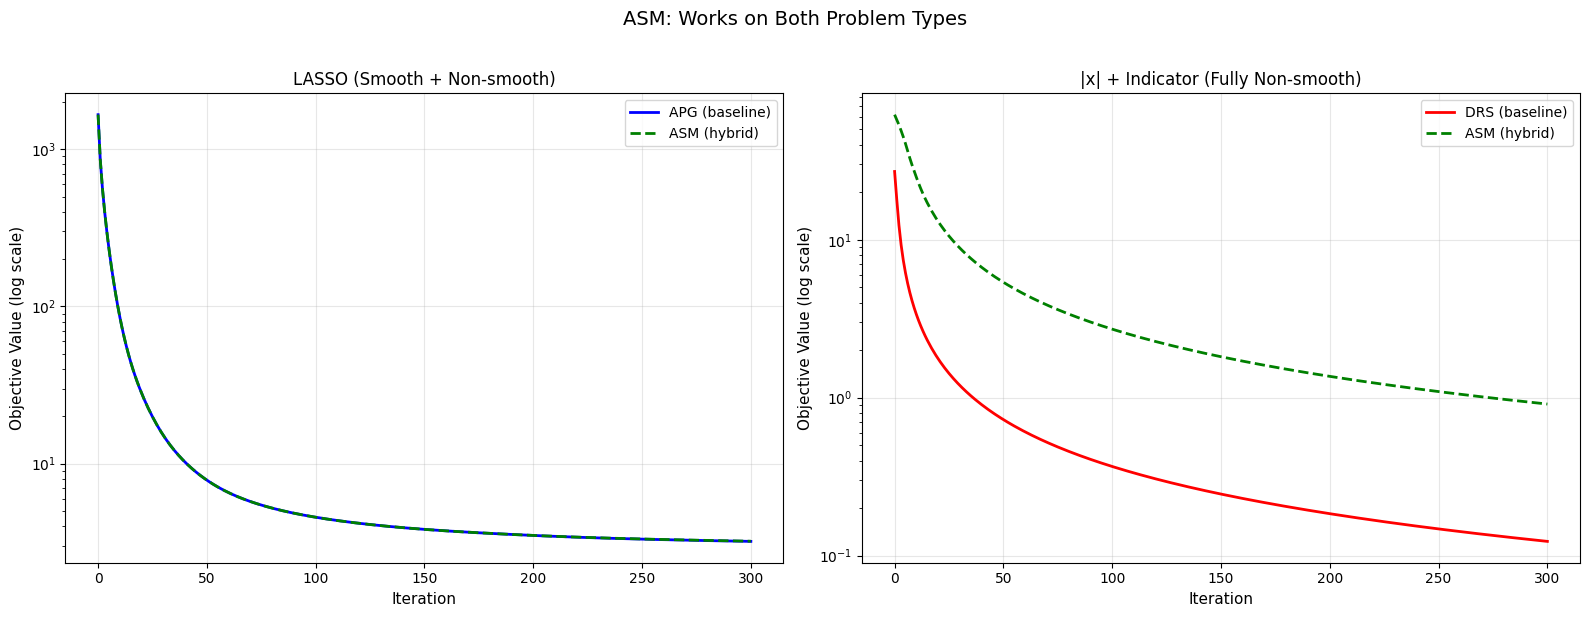


FINAL RESULTS after 300 iterations
LASSO:
  APG:           3.20522957
  ASM (hybrid): 3.21373462

|x| + Indicator:
  DRS:           0.12307919
  ASM (hybrid): 0.91118397


In [ ]:
# ============================================================================
# TEST UNIFIED ASM ON BOTH PROBLEM TYPES
# ============================================================================

print("="*80)
print("TEST 1: LASSO (Smooth + Non-smooth) - is_smooth=True")
print("="*80)

# Setup LASSO
A, b, F_lasso, grad_lasso, prox_l1 = setup_lasso(n=100, m=80, lambda_reg=0.1)
x0 = np.zeros(A.shape[1])
L = np.linalg.norm(A.T @ A, ord=2)
alpha = 1.0 / L

print("Running ASM (unified) on LASSO...")
_, obj_asm_lasso = asm_unified(x0, grad_lasso, prox_l1, F_lasso, 
                                alpha=alpha, is_smooth=True, max_iter=300)

print("Running APG (baseline) on LASSO...")
_, obj_apg_lasso = apg_generic(x0, grad_lasso, prox_l1, F_lasso, alpha, max_iter=300)

print("\n" + "="*80)
print("TEST 2: |x| + INDICATOR (Fully non-smooth) - is_smooth=False")
print("="*80)

# |x| + indicator
x0, F_abs, prox_abs, prox_ind = setup_problem1(n=100)
x0 = np.maximum(x0, 0)

def smooth_abs_grad_wrapper(x, mu=0.05):
    return x / np.sqrt(x**2 + mu**2)

print("Running ASM (unified) on |x|+indicator...")
_, obj_asm_nonsmooth = asm_unified(x0, smooth_abs_grad_wrapper, prox_abs, F_abs, 
                                    alpha=0.1, is_smooth=False, mu=0.05, max_iter=300)

print("Running DRS (baseline) on |x|+indicator...")
_, obj_drs_nonsmooth = drs_fully_nonsmooth(x0, prox_abs, prox_ind, F_abs, alpha=1.0, max_iter=300)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LASSO 
axes[0].semilogy(obj_apg_lasso, label='APG (baseline)', linewidth=2, color='blue')
axes[0].semilogy(obj_asm_lasso, label='ASM (hybrid)', linewidth=2, color='green', linestyle='--')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Objective Value (log scale)', fontsize=11)
axes[0].set_title('LASSO (Smooth + Non-smooth)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# |x| + Indicator 
axes[1].semilogy(obj_drs_nonsmooth, label='DRS (baseline)', linewidth=2, color='red')
axes[1].semilogy(obj_asm_nonsmooth, label='ASM (hybrid)', linewidth=2, color='green', linestyle='--')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Objective Value (log scale)', fontsize=11)
axes[1].set_title('|x| + Indicator (Fully Non-smooth)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ASM: Works on Both Problem Types', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL RESULTS after 300 iterations")
print("="*60)
print(f"LASSO:")
print(f"  APG:           {obj_apg_lasso[-1]:.8f}")
print(f"  ASM (hybrid): {obj_asm_lasso[-1]:.8f}")
print(f"\n|x| + Indicator:")
print(f"  DRS:           {obj_drs_nonsmooth[-1]:.8f}")
print(f"  ASM (hybrid): {obj_asm_nonsmooth[-1]:.8f}")
print("="*60)

# Another hybrid method

In [ ]:

def moreau_grad(x, prox_fn, alpha):
    u = prox_fn(x, alpha)
    return (x - u) / alpha

def smoothness_score(x, x_prev, grad, grad_prev):
    dx = x - x_prev
    dg = grad - grad_prev
    dx_norm = np.linalg.norm(dx)
    if dx_norm < 1e-10:
        return 0.0
    return np.linalg.norm(dg) / dx_norm

def prox_abs(x, alpha):
    return np.sign(x) * np.maximum(np.abs(x) - alpha, 0)

def prox_indicator(x, alpha=1.0, constraint='nonneg'):
    if constraint == 'nonneg':
        return np.maximum(x, 0)
    return x

def prox_l1(x, alpha, lam):
    return np.sign(x) * np.maximum(np.abs(x) - alpha * lam, 0)

# ── Objective functions ─────────────────────────────────────────────────────

def F_nonsmooth(x, constraint='nonneg'):
    proj = prox_indicator(x, constraint=constraint)
    if not np.allclose(x, proj):
        return np.inf
    return np.sum(np.abs(x))

def F_lasso(x, A, b, lam):
    return 0.5 * np.linalg.norm(A @ x - b)**2 + lam * np.sum(np.abs(x))

# ── Baseline methods ────────────────────────────────────────────────────────

def apg_lasso(x0, A, b, lam, max_iter=1000):
    """Standard APG for Lasso"""
    L = np.linalg.norm(A.T @ A, ord=2)
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    obj = [F_lasso(x, A, b, lam)]
    for _ in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        grad = A.T @ (A @ y - b)
        x_new = prox_l1(y - grad / L, 1.0 / L, lam)
        y = x_new + beta * (x_new - x)
        x = x_new
        t = t_new
        obj.append(F_lasso(x, A, b, lam))
    return x, np.array(obj)

def drs_nonsmooth(x0, max_iter=1000, constraint='nonneg'):
    """Standard DRS for |x| + indicator"""
    z = x0.copy()
    x_avg = prox_abs(z, 1.0)
    obj = [F_nonsmooth(x_avg, constraint)]
    for k in range(max_iter):
        x = prox_abs(z, 1.0)
        u = prox_indicator(2 * x - z, constraint=constraint)
        z = z + u - x
        x_avg = (k * x_avg + x) / (k + 1)
        obj.append(F_nonsmooth(x_avg, constraint))
    return x, np.array(obj)

def adrs_nonsmooth(x0, max_iter=1000, constraint='nonneg'):
    """Accelerated DRS for |x| + indicator"""
    z = x0.copy()
    z_prev = x0.copy()
    t = 1.0
    x = prox_abs(z, 1.0)
    x_avg = x.copy()
    obj = [F_nonsmooth(x_avg, constraint)]
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox_abs(y, 1.0)
        u = prox_indicator(2 * x - y, constraint=constraint)
        z_prev = z.copy()
        z = y + u - x
        t = t_new
        x_avg = (k * x_avg + x) / (k + 1)
        obj.append(F_nonsmooth(x_avg, constraint))
    return x, np.array(obj)




In [145]:
def hybrid_apg_drs_adaptive(
    x0,
    prox_f,
    prox_g,
    F_obj,
    grad_smooth=None,
    L_smooth=None,
    alpha_drs=1.0,
    alpha_moreau=0.1,
    switch_every=50,
    smooth_thresh=5.0,
    max_iter=1000,
    verbose=True,
    constraint='nonneg'
):
    n = len(x0)
    x = x0.copy()
    z = x0.copy()
    z_prev = x0.copy()
    y = x0.copy()
    t = 1.0
    x_avg = x.copy()
    obj = []
    mode_history = []

    grad_curr = moreau_grad(x, prox_f, alpha_moreau)
    grad_prev = grad_curr.copy()
    x_prev = x.copy()
    current_mode = 'unknown'

    for k in range(max_iter):

        if k % switch_every == 0:
            score = smoothness_score(x, x_prev, grad_curr, grad_prev)
            if grad_smooth is None:
                # No smooth part available — always stay in DRS mode
                new_mode = 'DRS'
            elif k == 0:
                new_mode = 'APG'
            else:
                new_mode = 'APG' if score < smooth_thresh else 'DRS'

            if new_mode != current_mode:
                if verbose and k > 0:
                    print(f"  [k={k}] Mode switch: {current_mode} -> {new_mode}  (score={score:.3f})")
                current_mode = new_mode
                t = 1.0
                z = x.copy()
                z_prev = x.copy()

        mode_history.append(current_mode)

        # APG mode
        if current_mode == 'APG':
            alpha_apg = 1.0 / L_smooth
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            x_new = prox_f(y - alpha_apg * grad_smooth(y), alpha_apg)
            y = x_new + beta * (x_new - x)
            x_prev = x.copy()
            grad_prev = grad_curr.copy()
            x = x_new
            grad_curr = moreau_grad(x, prox_f, alpha_moreau)
            t = t_new
            x_avg = x.copy()
            obj.append(F_obj(x))

        # DRS/ADRS mode
        else:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            beta = (t - 1) / t_new
            y_drs = z + beta * (z - z_prev)
            x_half = prox_f(y_drs, alpha_drs)
            u = prox_g(2 * x_half - y_drs, alpha_drs, constraint)
            z_prev = z.copy()
            z = y_drs + u - x_half
            x = x_half
            t = t_new
            x_avg = (k * x_avg + x) / (k + 1)
            x_prev = x.copy()
            grad_prev = grad_curr.copy()
            grad_curr = moreau_grad(x, prox_f, alpha_moreau)
            obj.append(F_obj(x_avg))

    if verbose:
        apg_c = sum(1 for m in mode_history if m == 'APG')
        drs_c = sum(1 for m in mode_history if m == 'DRS')
        print(f"  Mode summary: APG={apg_c} iters, DRS={drs_c} iters")

    return x, np.array(obj), mode_history

EXPERIMENT 1: LASSO
Running PG (baseline)...
Running APG (baseline)...
Running Hybrid (Lasso)...
  [k=200] Mode switch: APG -> DRS  (score=5.945)
  [k=250] Mode switch: DRS -> APG  (score=0.000)
  [k=300] Mode switch: APG -> DRS  (score=5.638)
  [k=350] Mode switch: DRS -> APG  (score=0.000)
  [k=400] Mode switch: APG -> DRS  (score=7.208)
  [k=450] Mode switch: DRS -> APG  (score=0.000)
  [k=500] Mode switch: APG -> DRS  (score=6.556)
  [k=550] Mode switch: DRS -> APG  (score=0.000)
  [k=600] Mode switch: APG -> DRS  (score=6.915)
  [k=650] Mode switch: DRS -> APG  (score=0.000)
  [k=700] Mode switch: APG -> DRS  (score=6.724)
  [k=750] Mode switch: DRS -> APG  (score=0.000)
  [k=800] Mode switch: APG -> DRS  (score=6.826)
  [k=850] Mode switch: DRS -> APG  (score=0.000)
  Mode summary: APG=1650 iters, DRS=350 iters


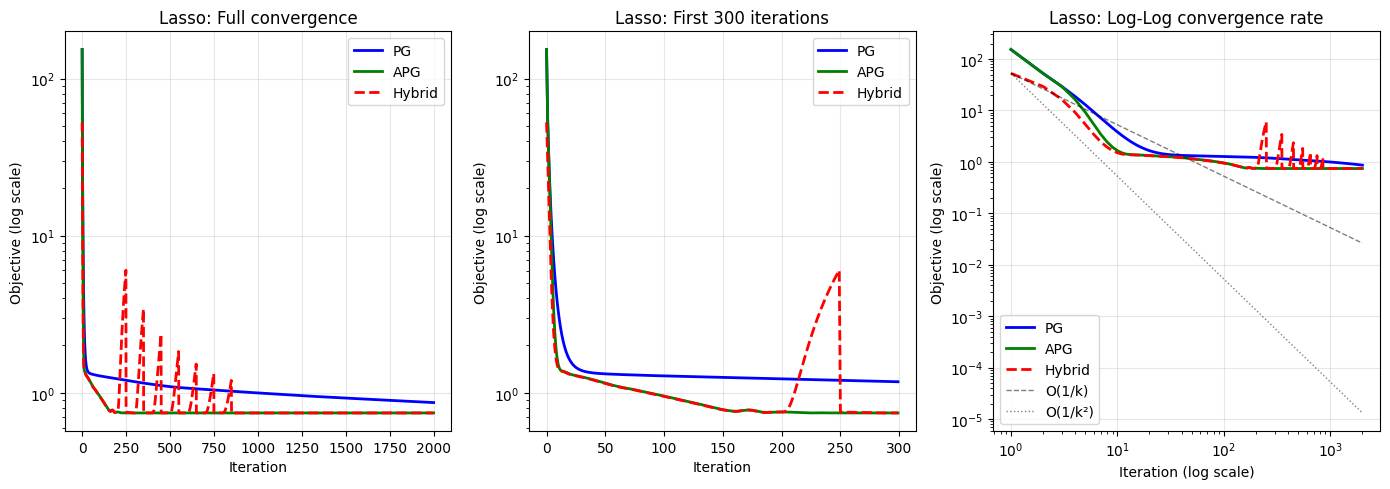


LASSO FINAL OBJECTIVE VALUES
  PG                  : 0.86524357
  APG                 : 0.74327899
  Hybrid              : 0.74327899

  BEST: APG with 0.74327899

  Iterations to match PG final accuracy (0.865244):
  PG                  :  2000 iters  (SPEEDUP: 1.00x vs PG)
  APG                 :   125 iters  (SPEEDUP: 16.01x vs PG)
  Hybrid              :   124 iters  (SPEEDUP: 16.14x vs PG)

EXPERIMENT 2: |x| + INDICATOR (nonneg)
Running DRS (baseline)...
Running ADRS...
Running Hybrid (nonsmooth)...
  Mode summary: APG=0 iters, DRS=3000 iters


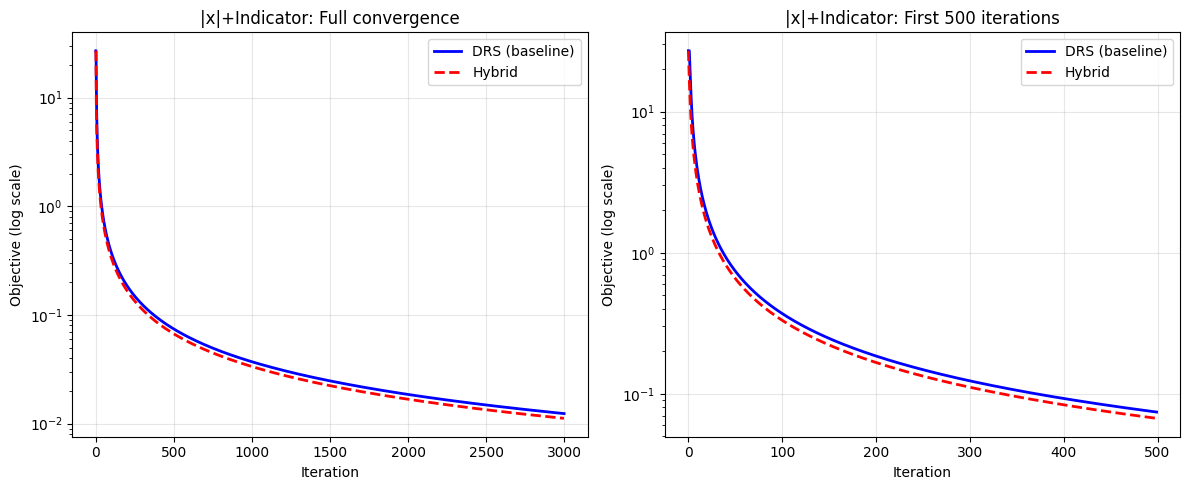


FINAL OBJECTIVE VALUES
Lasso:
  APG                 : 0.74327899
  Hybrid              : 0.74327899
|x| + Indicator:
  DRS                 : 0.01234894
  ADRS                : 0.01116503
  Hybrid              : 0.01116503


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Lasso
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("EXPERIMENT 1: LASSO")
print("=" * 60)

np.random.seed(42)
m, n = 50, 100
A = np.random.randn(m, n)
x_true = np.zeros(n)
x_true[:10] = np.random.randn(10)
b = A @ x_true + 0.01 * np.random.randn(m)
lam = 0.1
MAX_ITER = 2000

x0_lasso = np.zeros(n)
L_lasso = np.linalg.norm(A.T @ A, ord=2)

def grad_lasso(x):
    return A.T @ (A @ x - b)

def prox_l1_lasso(x, alpha):
    return prox_l1(x, alpha, lam)

def F_lasso_obj(x, *args):
    return F_lasso(x, A, b, lam)

def prox_none(x, alpha, constraint=None):
    return x

def pg_lasso(x0, A, b, lam, max_iter=1000):
    L = np.linalg.norm(A.T @ A, ord=2)
    x = x0.copy()
    obj = [F_lasso(x, A, b, lam)]
    for _ in range(max_iter):
        grad = A.T @ (A @ x - b)
        x = prox_l1(x - grad / L, 1.0 / L, lam)
        obj.append(F_lasso(x, A, b, lam))
    return x, np.array(obj)

print("Running PG (baseline)...")
_, obj_pg_lasso = pg_lasso(x0_lasso, A, b, lam, max_iter=MAX_ITER)

print("Running APG (baseline)...")
_, obj_apg_lasso = apg_lasso(x0_lasso, A, b, lam, max_iter=MAX_ITER)

print("Running Hybrid (Lasso)...")
_, obj_hybrid_lasso, modes_lasso = hybrid_apg_drs_adaptive(
    x0_lasso, prox_l1_lasso, prox_none, F_lasso_obj,
    grad_smooth=grad_lasso, L_smooth=L_lasso,
    max_iter=MAX_ITER, verbose=True, constraint='none'
)

lasso_methods = [
    (obj_pg_lasso,      'PG',     'blue',   '-'),
    (obj_apg_lasso,     'APG',    'green',  '-'),
    (obj_hybrid_lasso,  'Hybrid', 'red',    '--'),
]

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
for obj, label, color, ls in lasso_methods:
    obj_c = obj[np.isfinite(obj)]
    plt.semilogy(obj_c, label=label, linewidth=2, color=color, linestyle=ls)
plt.xlabel('Iteration'); plt.ylabel('Objective (log scale)')
plt.title('Lasso: Full convergence'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
for obj, label, color, ls in lasso_methods:
    obj_c = obj[np.isfinite(obj)]
    plt.semilogy(obj_c[:300], label=label, linewidth=2, color=color, linestyle=ls)
plt.xlabel('Iteration'); plt.ylabel('Objective (log scale)')
plt.title('Lasso: First 300 iterations'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
k = np.arange(1, MAX_ITER + 1)
ref_O1k  = obj_pg_lasso[1] / k
ref_O1k2 = obj_pg_lasso[1] / k**2
for obj, label, color, ls in lasso_methods:
    obj_c = obj[np.isfinite(obj)]
    iters = np.arange(1, len(obj_c) + 1)
    plt.loglog(iters, obj_c, label=label, linewidth=2, color=color, linestyle=ls)
plt.loglog(k, ref_O1k,  'k--', alpha=0.5, label='O(1/k)',  linewidth=1)
plt.loglog(k, ref_O1k2, 'k:',  alpha=0.5, label='O(1/k²)', linewidth=1)
plt.xlabel('Iteration (log scale)'); plt.ylabel('Objective (log scale)')
plt.title('Lasso: Log-Log convergence rate'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("LASSO FINAL OBJECTIVE VALUES")
print("=" * 60)
results_lasso = []
for name, obj in [('PG', obj_pg_lasso), ('APG', obj_apg_lasso), ('Hybrid', obj_hybrid_lasso)]:
    final = obj[np.isfinite(obj)][-1]
    results_lasso.append((name, final))
    print(f"  {name:20s}: {final:.8f}")

best_name, best_val = min(results_lasso, key=lambda x: x[1])
print(f"\n  BEST: {best_name} with {best_val:.8f}")

target = obj_pg_lasso[np.isfinite(obj_pg_lasso)][-1]
print(f"\n  Iterations to match PG final accuracy ({target:.6f}):")
pg_iters = len(obj_pg_lasso[np.isfinite(obj_pg_lasso)])
for name, obj in [('PG', obj_pg_lasso), ('APG', obj_apg_lasso), ('Hybrid', obj_hybrid_lasso)]:
    obj_c = obj[np.isfinite(obj)]
    for i, val in enumerate(obj_c):
        if val <= target:
            if i < pg_iters:
                print(f"  {name:20s}: {i:5d} iters  (SPEEDUP: {pg_iters/i:.2f}x vs PG)")
            else:
                print(f"  {name:20s}: {i:5d} iters  (same as PG)")
            break
    else:
        print(f"  {name:20s}: DID NOT REACH within {len(obj_c)} iters")

# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: |x| + Indicator
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXPERIMENT 2: |x| + INDICATOR (nonneg)")
print("=" * 60)

np.random.seed(42)
x0_ns = np.random.randn(100) * 2
x0_ns = prox_indicator(x0_ns, constraint='nonneg')
MAX_ITER_NS = 3000

print("Running DRS (baseline)...")
_, obj_drs_ns = drs_nonsmooth(x0_ns, max_iter=MAX_ITER_NS)

print("Running ADRS...")
_, obj_adrs_ns = adrs_nonsmooth(x0_ns, max_iter=MAX_ITER_NS)

print("Running Hybrid (nonsmooth)...")
_, obj_hybrid_ns, modes_ns = hybrid_apg_drs_adaptive(
    x0_ns, prox_abs, prox_indicator, F_nonsmooth,
    grad_smooth=None, max_iter=MAX_ITER_NS, verbose=True, constraint='nonneg'
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for obj, label, color, ls in [
    (obj_drs_ns,    'DRS (baseline)', 'blue',   '-'),
    # (obj_adrs_ns,   'ADRS',          'orange', '-'),
    (obj_hybrid_ns, 'Hybrid',        'red',    '--'),
]:
    obj_c = obj[np.isfinite(obj)]
    plt.semilogy(obj_c, label=label, linewidth=2, color=color, linestyle=ls)
plt.xlabel('Iteration'); plt.ylabel('Objective (log scale)')
plt.title('|x|+Indicator: Full convergence'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for obj, label, color, ls in [
    (obj_drs_ns,    'DRS (baseline)', 'blue',   '-'),
    # (obj_adrs_ns,   'ADRS',          'orange', '-'),
    (obj_hybrid_ns, 'Hybrid',        'red',    '--'),
]:
    obj_c = obj[np.isfinite(obj)]
    plt.semilogy(obj_c[:500], label=label, linewidth=2, color=color, linestyle=ls)
plt.xlabel('Iteration'); plt.ylabel('Objective (log scale)')
plt.title('|x|+Indicator: First 500 iterations'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("FINAL OBJECTIVE VALUES")
print("=" * 60)
print("Lasso:")
for name, obj in [('APG', obj_apg_lasso), ('Hybrid', obj_hybrid_lasso)]:
    print(f"  {name:20s}: {obj[np.isfinite(obj)][-1]:.8f}")
print("|x| + Indicator:")
for name, obj in [('DRS', obj_drs_ns), ('ADRS', obj_adrs_ns), ('Hybrid', obj_hybrid_ns)]:
    print(f"  {name:20s}: {obj[np.isfinite(obj)][-1]:.8f}")